In [708]:
import numpy as np
import pandas as pd

In [709]:
complete_df = pd.read_csv('complete_df.csv')

In [710]:
complete_df

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,9785323,NaN,28000,28000,28000.0,36 months,6.62,859.71,A,A2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,78558461,NaN,10650,10650,10650.0,36 months,25.11,424.07,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,110757806,NaN,18000,18000,18000.0,36 months,10.91,588.54,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,96668860,NaN,3975,3975,3975.0,36 months,17.99,143.69,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,118207599,NaN,4800,4800,4800.0,36 months,16.02,168.81,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,115090136,NaN,24000,24000,24000.0,60 months,9.44,503.35,B,B1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
99996,3365462,NaN,13000,13000,13000.0,36 months,13.11,438.72,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
99997,48605201,NaN,2500,2500,2500.0,36 months,15.61,87.42,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
99998,56117368,NaN,14400,14400,14400.0,60 months,9.17,300.11,B,B2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [711]:
complete_df.columns.to_list()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

In [712]:
complete_df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,9785323,NaN,28000,28000,28000.0,36 months,6.62,859.71,A,A2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,78558461,NaN,10650,10650,10650.0,36 months,25.11,424.07,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,110757806,NaN,18000,18000,18000.0,36 months,10.91,588.54,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,96668860,NaN,3975,3975,3975.0,36 months,17.99,143.69,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,118207599,NaN,4800,4800,4800.0,36 months,16.02,168.81,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [713]:
unique_statuses = complete_df['loan_status'].unique()

In [714]:
unique_statuses

array(['Fully Paid', 'Current', 'Charged Off', 'Late (31-120 days)',
       'Late (16-30 days)',
       'Does not meet the credit policy. Status:Charged Off',
       'Does not meet the credit policy. Status:Fully Paid',
       'In Grace Period', 'Default'], dtype=object)

In [715]:
bad_loan = ["Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off",
            "In Grace Period", "Late (16-30 days)", "Late (31-120 days)"]

In [716]:
complete_df['loan_condition_int'] = complete_df['loan_status'].apply(lambda status : 1 if status in bad_loan else 0).astype(int)

In [717]:
complete_df['loan_condition_int'].tail(10)

99990    0
99991    0
99992    0
99993    0
99994    0
99995    0
99996    0
99997    0
99998    1
99999    0
Name: loan_condition_int, dtype: int32

In [718]:
complete_df['loan_condition_int'].value_counts()

loan_condition_int
0    86628
1    13372
Name: count, dtype: int64

## Very Imbalanced 

loan_condition_int

0   =   86628

1   =   13372

Name: count, dtype: int64

In [719]:
complete_df['loan_condition'] = np.where(complete_df['loan_condition_int'] == 0, 'Good Loan', 'Bad Loan')

In [720]:
complete_df['loan_condition']

0        Good Loan
1        Good Loan
2        Good Loan
3        Good Loan
4        Good Loan
           ...    
99995    Good Loan
99996    Good Loan
99997    Good Loan
99998     Bad Loan
99999    Good Loan
Name: loan_condition, Length: 100000, dtype: object

In [721]:
complete_df['emp_length'].unique()

array(['10+ years', '9 years', '2 years', '< 1 year', '8 years',
       '7 years', '6 years', nan, '4 years', '1 year', '5 years',
       '3 years'], dtype=object)

In [722]:
emp_length_mapping = {
    '10+ years': 10,
    '9 years': 9,
    '8 years': 8,
    '7 years': 7,
    '6 years': 6,
    '5 years': 5,
    '4 years': 4,
    '3 years': 3,
    '2 years': 2,
    '1 year': 1,
    '< 1 year': 0.5,
    'nan': 0
}

In [723]:
complete_df['emp_length_int'] = complete_df['emp_length'].map(emp_length_mapping)

In [724]:
complete_df['emp_length_int'].head()

0    10.0
1    10.0
2     9.0
3     2.0
4     0.5
Name: emp_length_int, dtype: float64

In [725]:
complete_df['emp_length_int'].value_counts()

emp_length_int
10.0    33050
2.0      9047
0.5      8500
3.0      7946
1.0      6597
5.0      6181
4.0      5960
6.0      4454
7.0      4178
8.0      4085
9.0      3471
Name: count, dtype: int64

In [726]:
complete_df['addr_state'].unique()

array(['PA', 'WA', 'FL', 'NC', 'VA', 'NJ', 'OR', 'IN', 'TX', 'CA', 'MA',
       'NY', 'AL', 'GA', 'AZ', 'OK', 'LA', 'IL', 'CO', 'WV', 'MN', 'OH',
       'TN', 'NM', 'HI', 'MO', 'MD', 'WI', 'MI', 'UT', 'WY', 'NV', 'SC',
       'NE', 'KY', 'RI', 'MS', 'CT', 'MT', 'DC', 'AK', 'DE', 'SD', 'AR',
       'NH', 'KS', 'ID', 'ME', 'ND', 'VT'], dtype=object)

In [727]:
state_to_region = {
    'CA': 'West', 'OR': 'West', 'UT': 'West', 'WA': 'West', 'CO': 'West',
    'NV': 'West', 'AK': 'West', 'MT': 'West', 'HI': 'West', 'WY': 'West', 'ID': 'West',
    'AZ': 'SouthWest', 'TX': 'SouthWest', 'NM': 'SouthWest', 'OK': 'SouthWest',
    'GA': 'SouthEast', 'NC': 'SouthEast', 'VA': 'SouthEast', 'FL': 'SouthEast', 'KY': 'SouthEast',
    'SC': 'SouthEast', 'LA': 'SouthEast', 'AL': 'SouthEast', 'WV': 'SouthEast', 'DC': 'SouthEast',
    'AR': 'SouthEast', 'DE': 'SouthEast', 'MS': 'SouthEast', 'TN': 'SouthEast',
    'IL': 'MidWest', 'MO': 'MidWest', 'MN': 'MidWest', 'OH': 'MidWest', 'WI': 'MidWest',
    'KS': 'MidWest', 'MI': 'MidWest', 'SD': 'MidWest', 'IA': 'MidWest', 'NE': 'MidWest',
    'IN': 'MidWest', 'ND': 'MidWest',
    'CT': 'NorthEast', 'NY': 'NorthEast', 'PA': 'NorthEast', 'NJ': 'NorthEast', 'RI': 'NorthEast',
    'MA': 'NorthEast', 'MD': 'NorthEast', 'VT': 'NorthEast', 'NH': 'NorthEast', 'ME': 'NorthEast'
}

In [728]:
complete_df['region'] = complete_df['addr_state'].map(state_to_region)

In [729]:
complete_df['region'].value_counts()

region
SouthEast    24329
NorthEast    23006
West         22837
MidWest      17737
SouthWest    12091
Name: count, dtype: int64

In [730]:
complete_df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,loan_condition_int,loan_condition,emp_length_int,region
0,9785323,NaN,28000,28000,28000.0,36 months,6.62,859.71,A,A2,...,NaN,NaN,NaN,NaN,NaN,NaN,0,Good Loan,10.0,NorthEast
1,78558461,NaN,10650,10650,10650.0,36 months,25.11,424.07,F,F1,...,NaN,NaN,NaN,NaN,NaN,NaN,0,Good Loan,10.0,West
2,110757806,NaN,18000,18000,18000.0,36 months,10.91,588.54,B,B4,...,NaN,NaN,NaN,NaN,NaN,NaN,0,Good Loan,9.0,SouthEast
3,96668860,NaN,3975,3975,3975.0,36 months,17.99,143.69,D,D2,...,NaN,NaN,NaN,NaN,NaN,NaN,0,Good Loan,2.0,SouthEast
4,118207599,NaN,4800,4800,4800.0,36 months,16.02,168.81,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,0,Good Loan,0.5,SouthEast


In [731]:
complete_df.isnull().sum()

id                         0
member_id             100000
loan_amnt                  0
funded_amnt                0
funded_amnt_inv            0
                       ...  
settlement_term        98497
loan_condition_int         0
loan_condition             0
emp_length_int          6531
region                     0
Length: 155, dtype: int64

In [732]:
complete_df.isnull().sum().to_list()

[0,
 100000,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 7421,
 6531,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 94287,
 0,
 1021,
 0,
 0,
 72,
 0,
 0,
 0,
 0,
 0,
 51210,
 84261,
 0,
 0,
 0,
 84,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 120,
 0,
 59586,
 2,
 0,
 0,
 5,
 74306,
 0,
 0,
 94691,
 94691,
 94899,
 0,
 3105,
 3105,
 38548,
 38548,
 38548,
 38548,
 40616,
 38548,
 47537,
 38548,
 38548,
 38548,
 38555,
 3105,
 38548,
 38548,
 38548,
 2170,
 3108,
 3250,
 3302,
 5,
 0,
 6288,
 3105,
 3105,
 3105,
 2170,
 3174,
 76908,
 13159,
 67099,
 3105,
 3105,
 3105,
 2559,
 3105,
 3105,
 3105,
 3105,
 3105,
 2559,
 6824,
 3105,
 3105,
 3105,
 3113,
 3271,
 70,
 5,
 3105,
 2170,
 2170,
 3105,
 95198,
 95198,
 95198,
 95198,
 95198,
 95198,
 95198,
 95282,
 95198,
 95198,
 95198,
 95198,
 98422,
 0,
 99530,
 99530,
 99530,
 99530,
 99530,
 99530,
 99530,
 99530,
 99530,
 99530,
 99530,
 99639,
 99530,
 99530,
 0,
 0,
 98497,
 98497,
 98497,
 98497,
 98497,
 98497,
 0,
 0,
 6531,
 0]

# EDA

In [733]:
EDA_df = complete_df.copy()

In [734]:
EDA_cat_columns = EDA_df.select_dtypes(include=['object']).columns.tolist()

In [735]:
EDA_cat_columns

['term',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'earliest_cr_line',
 'initial_list_status',
 'last_pymnt_d',
 'next_pymnt_d',
 'last_credit_pull_d',
 'application_type',
 'verification_status_joint',
 'sec_app_earliest_cr_line',
 'hardship_flag',
 'hardship_type',
 'hardship_reason',
 'hardship_status',
 'hardship_start_date',
 'hardship_end_date',
 'payment_plan_start_date',
 'hardship_loan_status',
 'disbursement_method',
 'debt_settlement_flag',
 'debt_settlement_flag_date',
 'settlement_status',
 'settlement_date',
 'loan_condition',
 'region']

In [736]:
EDA_df = complete_df.copy()

In [737]:
EDA_cat_columns = EDA_df.select_dtypes(include=['object']).columns.tolist()

In [738]:
EDA_cat_columns

['term',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'earliest_cr_line',
 'initial_list_status',
 'last_pymnt_d',
 'next_pymnt_d',
 'last_credit_pull_d',
 'application_type',
 'verification_status_joint',
 'sec_app_earliest_cr_line',
 'hardship_flag',
 'hardship_type',
 'hardship_reason',
 'hardship_status',
 'hardship_start_date',
 'hardship_end_date',
 'payment_plan_start_date',
 'hardship_loan_status',
 'disbursement_method',
 'debt_settlement_flag',
 'debt_settlement_flag_date',
 'settlement_status',
 'settlement_date',
 'loan_condition',
 'region']

In [739]:
EDA_num_columns = EDA_df.select_dtypes(exclude=['object']).columns.tolist()

In [740]:
EDA_cat_columns

['term',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'earliest_cr_line',
 'initial_list_status',
 'last_pymnt_d',
 'next_pymnt_d',
 'last_credit_pull_d',
 'application_type',
 'verification_status_joint',
 'sec_app_earliest_cr_line',
 'hardship_flag',
 'hardship_type',
 'hardship_reason',
 'hardship_status',
 'hardship_start_date',
 'hardship_end_date',
 'payment_plan_start_date',
 'hardship_loan_status',
 'disbursement_method',
 'debt_settlement_flag',
 'debt_settlement_flag_date',
 'settlement_status',
 'settlement_date',
 'loan_condition',
 'region']

In [741]:
filtered_EDA_cat_columns = [col for col in EDA_cat_columns if EDA_df[col].nunique() <= 50]

In [742]:
filtered_EDA_cat_columns

['term',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'verification_status',
 'loan_status',
 'pymnt_plan',
 'purpose',
 'addr_state',
 'initial_list_status',
 'application_type',
 'verification_status_joint',
 'hardship_flag',
 'hardship_type',
 'hardship_reason',
 'hardship_status',
 'hardship_start_date',
 'hardship_end_date',
 'payment_plan_start_date',
 'hardship_loan_status',
 'disbursement_method',
 'debt_settlement_flag',
 'settlement_status',
 'loan_condition',
 'region']

In [743]:
print(f"Numerical columns for EDA: {EDA_num_columns}")
print(f"Categorical columns for EDA: {filtered_EDA_cat_columns}")

Numerical columns for EDA: ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'annual_inc_joint', 'dti_joint', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc

In [744]:
import matplotlib.pyplot as plt
import seaborn as sns

In [745]:
EDA_df['is_default'] = EDA_df['loan_status'].isin(bad_loan).astype(int)

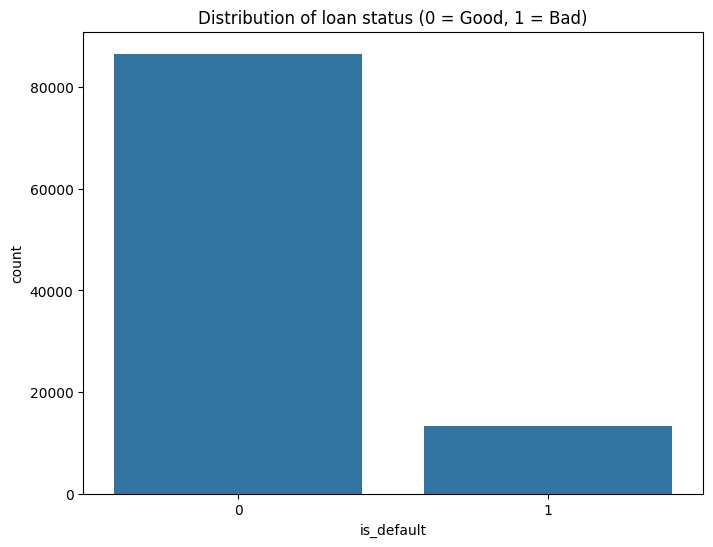

In [746]:
plt.figure(figsize=(8,6))
sns.countplot(x = 'is_default', data = EDA_df)
plt.title('Distribution of loan status (0 = Good, 1 = Bad)')
plt.show()

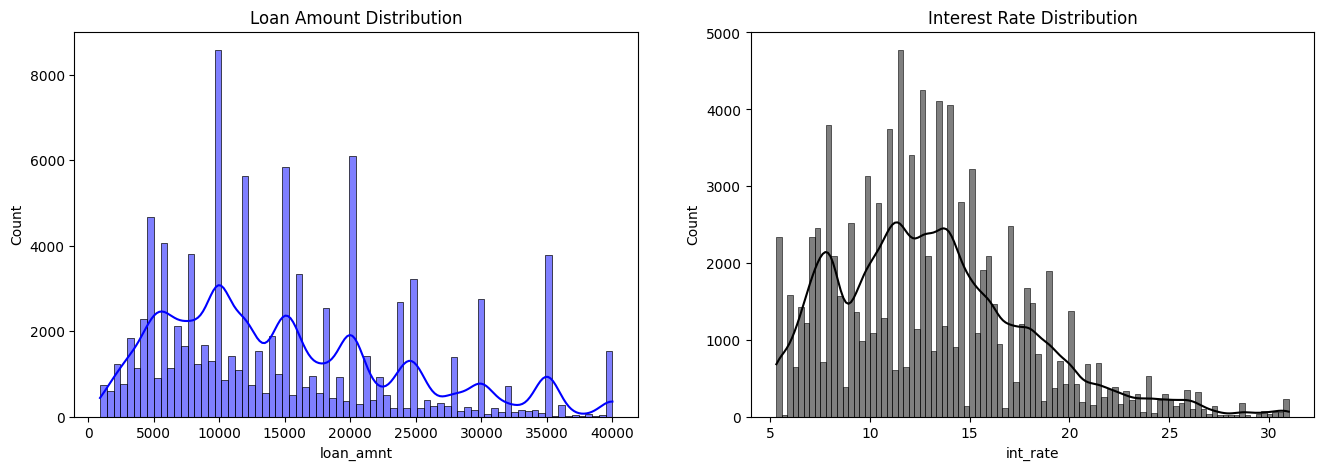

In [747]:
fig, axes = plt.subplots(1,2, figsize=(16, 5))
# 1st
sns.histplot(EDA_df['loan_amnt'], kde = True, ax = axes[0], color='blue')
axes[0].set_title('Loan Amount Distribution')
# 2nd
sns.histplot(EDA_df['int_rate'], kde=True, ax = axes[1], color= 'black')
axes[1].set_title('Interest Rate Distribution')

plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26204\1241795337.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=EDA_df, x='is_default', y='loan_amnt', ax=axes[0], palette='Set2')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26204\1241795337.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=EDA_df, x='is_default', y='int_rate', ax=axes[1], palette='Set2')


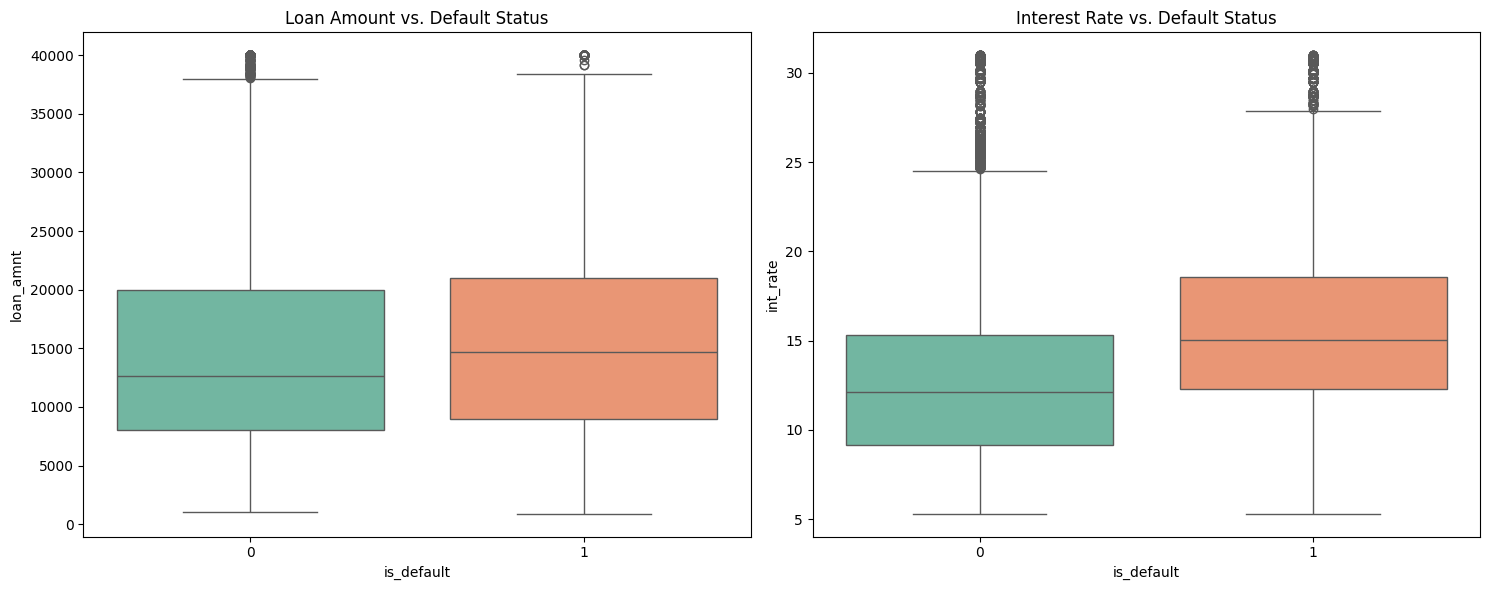

In [748]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=EDA_df, x='is_default', y='loan_amnt', ax=axes[0], palette='Set2')
axes[0].set_title('Loan Amount vs. Default Status')

sns.boxplot(data=EDA_df, x='is_default', y='int_rate', ax=axes[1], palette='Set2')
axes[1].set_title('Interest Rate vs. Default Status')

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

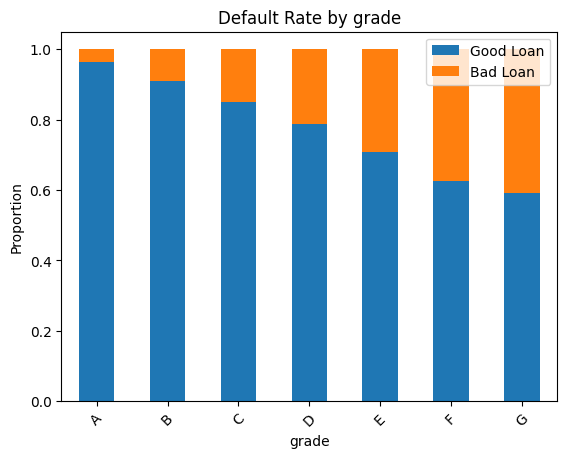

<Figure size 1200x600 with 0 Axes>

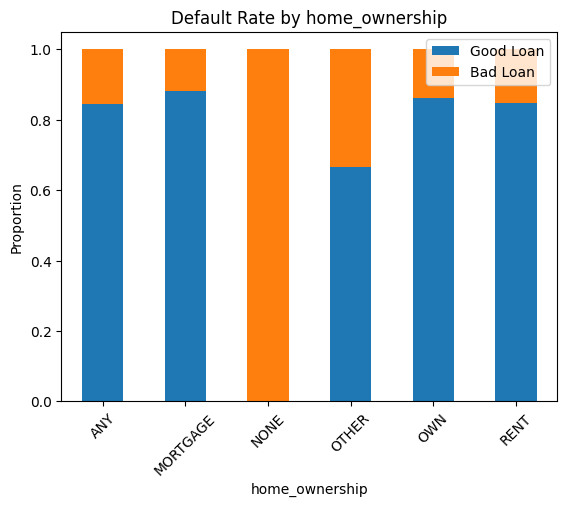

<Figure size 1200x600 with 0 Axes>

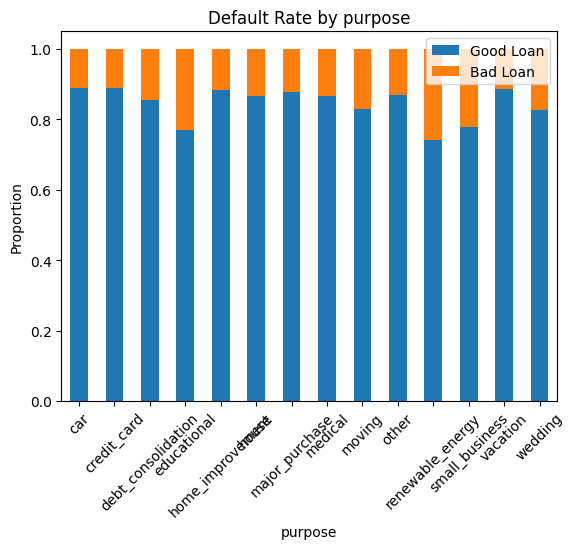

<Figure size 1200x600 with 0 Axes>

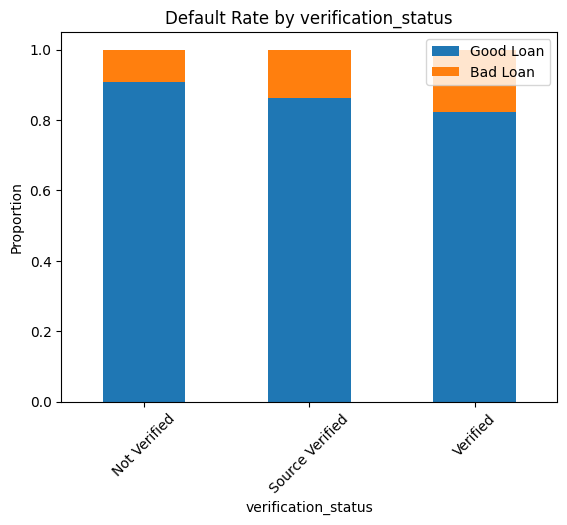

<Figure size 1200x600 with 0 Axes>

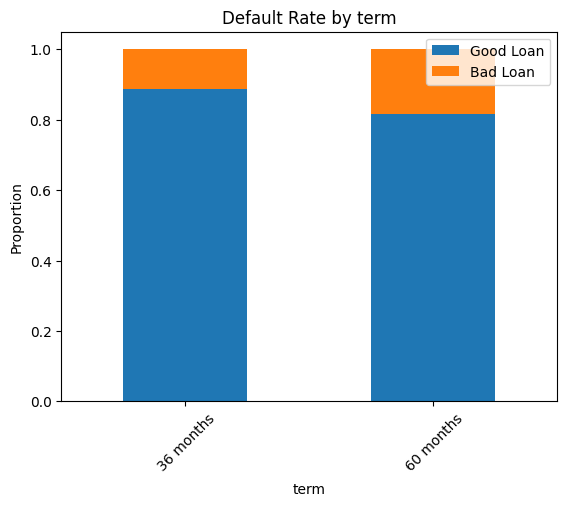

In [749]:
categorical_features_to_plot = ['grade', 'home_ownership', 'purpose', 'verification_status', 'term']
for col in categorical_features_to_plot:
    plt.figure(figsize=(12, 6))
    # Count the number of good and bad loans for each category
    counts = EDA_df.groupby([col, 'is_default']).size().unstack(fill_value=0)
    # Normalize to show the percentage of defaults for each category
    default_rate = counts.div(counts.sum(axis=1), axis=0)
    default_rate.plot(kind='bar', stacked=True)
    plt.title(f'Default Rate by {col}')
    plt.ylabel('Proportion')
    plt.legend(['Good Loan', 'Bad Loan'])
    plt.xticks(rotation=45)
    plt.show()

# Data Cleaning

In [750]:
complete_df.dtypes

id                      int64
member_id             float64
loan_amnt               int64
funded_amnt             int64
funded_amnt_inv       float64
                       ...   
settlement_term       float64
loan_condition_int      int32
loan_condition         object
emp_length_int        float64
region                 object
Length: 155, dtype: object

In [751]:
pd.value_counts(complete_df.loan_status).to_frame().reset_index()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26204\3920205029.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(complete_df.loan_status).to_frame().reset_index()


,loan_status,count
0,Fully Paid,47718
1,Current,38822
2,Charged Off,11868
3,Late (31-120 days),946
4,In Grace Period,335
5,Late (16-30 days),185
6,Does not meet the credit policy. Status:Fully ...,88
7,Does not meet the credit policy. Status:Charge...,36
8,Default,2


In [752]:
drop_df = complete_df
drop_df = complete_df[~complete_df['loan_status'].isin(['Current', 'Issued'])]

In [753]:
drop_df

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,loan_condition_int,loan_condition,emp_length_int,region
0,9785323,NaN,28000,28000,28000.0,36 months,6.62,859.71,A,A2,...,NaN,NaN,NaN,NaN,NaN,NaN,0,Good Loan,10.0,NorthEast
1,78558461,NaN,10650,10650,10650.0,36 months,25.11,424.07,F,F1,...,NaN,NaN,NaN,NaN,NaN,NaN,0,Good Loan,10.0,West
3,96668860,NaN,3975,3975,3975.0,36 months,17.99,143.69,D,D2,...,NaN,NaN,NaN,NaN,NaN,NaN,0,Good Loan,2.0,SouthEast
6,65773560,NaN,15000,15000,15000.0,36 months,6.24,457.97,A,A2,...,NaN,NaN,NaN,NaN,NaN,NaN,0,Good Loan,8.0,SouthEast
8,8604784,NaN,8000,8000,8000.0,36 months,9.67,256.90,B,B1,...,NaN,NaN,NaN,NaN,NaN,NaN,0,Good Loan,10.0,MidWest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99992,55298455,NaN,35000,35000,35000.0,60 months,17.57,880.61,D,D4,...,NaN,NaN,NaN,NaN,NaN,NaN,0,Good Loan,10.0,SouthEast
99996,3365462,NaN,13000,13000,13000.0,36 months,13.11,438.72,B,B4,...,NaN,NaN,NaN,NaN,NaN,NaN,0,Good Loan,8.0,West
99997,48605201,NaN,2500,2500,2500.0,36 months,15.61,87.42,D,D1,...,NaN,NaN,NaN,NaN,NaN,NaN,0,Good Loan,2.0,MidWest
99998,56117368,NaN,14400,14400,14400.0,60 months,9.17,300.11,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,1,Bad Loan,8.0,SouthEast


In [754]:
print(f"Original data size: {len(complete_df)}")
print(f"Cleaned data size: {len(drop_df)}")
print(f"Percentage of data kept: {round(len(drop_df)/len(complete_df)*100, 2)}%")

Original data size: 100000
Cleaned data size: 61178
Percentage of data kept: 61.18%


In [755]:
def get_missing_value_stats(input_df):
    df_null = pd.DataFrame({
        'Missing Count' : input_df.isnull().sum(),
        'Missing Percent' : 100 * input_df.isnull().sum() / len(input_df),
        'Type' : input_df.dtypes
    })

    missing_values = df_null[df_null['Missing Count']>0].sort_values(by='Missing Count', ascending= False)
    return missing_values

In [756]:
def get_value_stats(input_df):
    df_null = pd.DataFrame({
        'Count': input_df.notna().sum(),
        'Populated' : 100 * input_df.notna().sum() / len(input_df),
        'Unique_values' : input_df.nunique(),
        'Most Common Value' : input_df.mode().iloc[0],
        'Type' : input_df.dtypes
    })
    missing_values = df_null[df_null['Count'] > 0].sort_values(by='#Count', ascending=False)
    return missing_values

In [757]:
get_missing_value_stats(drop_df)

,Missing Count,Missing Percent,Type
member_id,61178,100.000000,float64
orig_projected_additional_accrued_interest,60930,99.594626,float64
sec_app_mths_since_last_major_derog,60832,99.434437,float64
hardship_reason,60824,99.421361,object
hardship_dpd,60824,99.421361,float64
...,...,...,...
dti,28,0.045768,float64
chargeoff_within_12_mths,5,0.008173,float64
collections_12_mths_ex_med,5,0.008173,float64
tax_liens,5,0.008173,float64


In [758]:
drop_df = drop_df.dropna(axis= 1, thresh= int(0.20*len(drop_df)))

In [759]:
drop_df.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,loan_condition_int,loan_condition,emp_length_int,region
0,9785323,28000,28000,28000.0,36 months,6.62,859.71,A,A2,regional manager,...,82341.0,6100.0,68795.0,N,Cash,N,0,Good Loan,10.0,NorthEast
1,78558461,10650,10650,10650.0,36 months,25.11,424.07,F,F1,TRUCK DRIVER,...,35276.0,10700.0,37183.0,N,Cash,N,0,Good Loan,10.0,West
3,96668860,3975,3975,3975.0,36 months,17.99,143.69,D,D2,Service Advisor,...,31940.0,4000.0,33457.0,N,Cash,N,0,Good Loan,2.0,SouthEast
6,65773560,15000,15000,15000.0,36 months,6.24,457.97,A,A2,Professor,...,129514.0,72000.0,132000.0,N,Cash,N,0,Good Loan,8.0,SouthEast
8,8604784,8000,8000,8000.0,36 months,9.67,256.90,B,B1,Lead Mammographer,...,24434.0,11000.0,20350.0,N,Cash,N,0,Good Loan,10.0,MidWest


In [760]:
get_missing_value_stats(drop_df)

,Missing Count,Missing Percent,Type
mths_since_recent_bc_dlq,46552,76.092713,float64
mths_since_last_major_derog,44984,73.529700,float64
mths_since_recent_revol_delinq,40485,66.175749,float64
il_util,39485,64.541175,float64
mths_since_rcnt_il,36807,60.163784,float64
...,...,...,...
dti,28,0.045768,float64
collections_12_mths_ex_med,5,0.008173,float64
tax_liens,5,0.008173,float64
chargeoff_within_12_mths,5,0.008173,float64


In [761]:
direct_indicators = [
    'collection_recovery_fee',
    'last_pymnt_amnt',
    'out_prncp',
    'out_prncp_inv',
    'recoveries',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_int',
    'total_rec_late_fee',
    'total_rec_prncp'
]

In [762]:
drop_df.drop(direct_indicators, axis = 1, inplace= True, errors= 'ignore')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26204\2973287807.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drop_df.drop(direct_indicators, axis = 1, inplace= True, errors= 'ignore')


In [763]:
drop_df.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,loan_condition_int,loan_condition,emp_length_int,region
0,9785323,28000,28000,28000.0,36 months,6.62,859.71,A,A2,regional manager,...,82341.0,6100.0,68795.0,N,Cash,N,0,Good Loan,10.0,NorthEast
1,78558461,10650,10650,10650.0,36 months,25.11,424.07,F,F1,TRUCK DRIVER,...,35276.0,10700.0,37183.0,N,Cash,N,0,Good Loan,10.0,West
3,96668860,3975,3975,3975.0,36 months,17.99,143.69,D,D2,Service Advisor,...,31940.0,4000.0,33457.0,N,Cash,N,0,Good Loan,2.0,SouthEast
6,65773560,15000,15000,15000.0,36 months,6.24,457.97,A,A2,Professor,...,129514.0,72000.0,132000.0,N,Cash,N,0,Good Loan,8.0,SouthEast
8,8604784,8000,8000,8000.0,36 months,9.67,256.90,B,B1,Lead Mammographer,...,24434.0,11000.0,20350.0,N,Cash,N,0,Good Loan,10.0,MidWest


In [764]:
#drop repeated features
drop_df.drop(['loan_condition'], axis=1, inplace=True)
drop_df.drop(['loan_status'], axis=1, inplace=True)
drop_df.drop(['emp_length'], axis=1, inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26204\551744194.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drop_df.drop(['loan_condition'], axis=1, inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26204\551744194.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drop_df.drop(['loan_status'], axis=1, inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26204\551744194.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-

In [765]:
drop_df.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,loan_condition_int,emp_length_int,region
0,9785323,28000,28000,28000.0,36 months,6.62,859.71,A,A2,regional manager,...,303786.0,82341.0,6100.0,68795.0,N,Cash,N,0,10.0,NorthEast
1,78558461,10650,10650,10650.0,36 months,25.11,424.07,F,F1,TRUCK DRIVER,...,234468.0,35276.0,10700.0,37183.0,N,Cash,N,0,10.0,West
3,96668860,3975,3975,3975.0,36 months,17.99,143.69,D,D2,Service Advisor,...,46857.0,31940.0,4000.0,33457.0,N,Cash,N,0,2.0,SouthEast
6,65773560,15000,15000,15000.0,36 months,6.24,457.97,A,A2,Professor,...,692644.0,129514.0,72000.0,132000.0,N,Cash,N,0,8.0,SouthEast
8,8604784,8000,8000,8000.0,36 months,9.67,256.90,B,B1,Lead Mammographer,...,167050.0,24434.0,11000.0,20350.0,N,Cash,N,0,10.0,MidWest


In [766]:
drop_df.drop(['id','emp_title','url','title','zip_code'], axis=1, inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26204\3455408307.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drop_df.drop(['id','emp_title','url','title','zip_code'], axis=1, inplace=True)


In [767]:
drop_df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,loan_condition_int,emp_length_int,region
0,28000,28000,28000.0,36 months,6.62,859.71,A,A2,MORTGAGE,125000.0,...,303786.0,82341.0,6100.0,68795.0,N,Cash,N,0,10.0,NorthEast
1,10650,10650,10650.0,36 months,25.11,424.07,F,F1,MORTGAGE,83000.0,...,234468.0,35276.0,10700.0,37183.0,N,Cash,N,0,10.0,West
3,3975,3975,3975.0,36 months,17.99,143.69,D,D2,ANY,43000.0,...,46857.0,31940.0,4000.0,33457.0,N,Cash,N,0,2.0,SouthEast
6,15000,15000,15000.0,36 months,6.24,457.97,A,A2,MORTGAGE,231800.0,...,692644.0,129514.0,72000.0,132000.0,N,Cash,N,0,8.0,SouthEast
8,8000,8000,8000.0,36 months,9.67,256.90,B,B1,MORTGAGE,72000.0,...,167050.0,24434.0,11000.0,20350.0,N,Cash,N,0,10.0,MidWest


In [768]:
drop_df.select_dtypes(include=["object"]).nunique()  

term                      2
grade                     7
sub_grade                35
home_ownership            6
verification_status       3
issue_d                 138
pymnt_plan                2
purpose                  14
addr_state               50
earliest_cr_line        630
initial_list_status       2
last_pymnt_d            134
last_credit_pull_d      123
application_type          2
hardship_flag             2
disbursement_method       2
debt_settlement_flag      2
region                    5
dtype: int64

In [769]:
drop_df.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'pymnt_plan', 'purpose', 'addr_state',
       'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low',
       'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'last_pymnt_d', 'last_credit_pull_d',
       'last_fico_range_high', 'last_fico_range_low',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt',
       'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m',
       'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util',
       'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
       'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths

In [770]:
drop_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61178 entries, 0 to 99999
Data columns (total 97 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   loan_amnt                       61178 non-null  int64  
 1   funded_amnt                     61178 non-null  int64  
 2   funded_amnt_inv                 61178 non-null  float64
 3   term                            61178 non-null  object 
 4   int_rate                        61178 non-null  float64
 5   installment                     61178 non-null  float64
 6   grade                           61178 non-null  object 
 7   sub_grade                       61178 non-null  object 
 8   home_ownership                  61178 non-null  object 
 9   annual_inc                      61178 non-null  float64
 10  verification_status             61178 non-null  object 
 11  issue_d                         61178 non-null  object 
 12  pymnt_plan                      61178

In [771]:
drop_df.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,...,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,loan_condition_int,emp_length_int
count,61178.000000,61178.000000,61178.000000,61178.000000,61178.000000,6.117800e+04,61150.000000,61178.000000,61178.000000,61178.000000,...,58065.000000,58360.000000,61108.000000,61173.000000,5.807300e+04,5.900800e+04,59008.000000,58073.000000,61178.000000,57530.000000
mean,14483.826294,14477.038723,14449.917643,13.319732,439.932214,7.638169e+04,18.321351,0.318922,695.949034,699.949197,...,94.129639,45.279492,0.134663,0.053095,1.744670e+05,4.979488e+04,21594.022929,42140.530419,0.218575,5.997758
std,8738.674152,8735.469129,8741.760842,4.759902,262.605684,6.066577e+04,10.276638,0.877070,31.734335,31.735105,...,8.815961,35.908522,0.379375,0.467710,1.863568e+05,4.847085e+04,21443.234189,43185.006272,0.413283,3.629727
min,900.000000,900.000000,0.000000,5.310000,22.790000,0.000000e+00,0.000000,0.000000,630.000000,634.000000,...,16.700000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.500000
25%,8000.000000,8000.000000,7950.000000,9.800000,250.290000,4.560000e+04,11.800000,0.000000,670.000000,674.000000,...,91.300000,11.100000,0.000000,0.000000,4.937800e+04,2.090300e+04,7800.000000,14866.000000,0.000000,2.000000
50%,12000.000000,12000.000000,12000.000000,12.790000,376.480000,6.500000e+04,17.660000,0.000000,690.000000,694.000000,...,97.800000,42.900000,0.000000,0.000000,1.108190e+05,3.739900e+04,15100.000000,31687.000000,0.000000,6.000000
75%,20000.000000,20000.000000,20000.000000,16.020000,582.080000,9.000000e+04,24.130000,0.000000,710.000000,714.000000,...,100.000000,75.000000,0.000000,0.000000,2.522330e+05,6.272650e+04,28000.000000,56713.000000,0.000000,10.000000
max,40000.000000,40000.000000,40000.000000,30.990000,1566.800000,4.860012e+06,999.000000,24.000000,845.000000,850.000000,...,100.000000,100.000000,8.000000,46.000000,9.999999e+06,2.644442e+06,335600.000000,840527.000000,1.000000,10.000000


# Missing Value Imputation

In [772]:
fillna_df = drop_df.copy()

In [773]:
fillna_df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,loan_condition_int,emp_length_int,region
0,28000,28000,28000.0,36 months,6.62,859.71,A,A2,MORTGAGE,125000.0,...,303786.0,82341.0,6100.0,68795.0,N,Cash,N,0,10.0,NorthEast
1,10650,10650,10650.0,36 months,25.11,424.07,F,F1,MORTGAGE,83000.0,...,234468.0,35276.0,10700.0,37183.0,N,Cash,N,0,10.0,West
3,3975,3975,3975.0,36 months,17.99,143.69,D,D2,ANY,43000.0,...,46857.0,31940.0,4000.0,33457.0,N,Cash,N,0,2.0,SouthEast
6,15000,15000,15000.0,36 months,6.24,457.97,A,A2,MORTGAGE,231800.0,...,692644.0,129514.0,72000.0,132000.0,N,Cash,N,0,8.0,SouthEast
8,8000,8000,8000.0,36 months,9.67,256.90,B,B1,MORTGAGE,72000.0,...,167050.0,24434.0,11000.0,20350.0,N,Cash,N,0,10.0,MidWest


In [774]:
for column in ['last_pymnt_d', 'last_credit_pull_d']:
    fillna_df[column] = fillna_df.groupby('region')[column].transform(lambda x : x.fillna(x.mode()))


In [775]:
fillna_df["pub_rec"] = fillna_df.groupby("region")["pub_rec"].transform(lambda x: x.fillna(x.median()))

In [776]:
fillna_df['pub_rec'].isnull().sum()

0

In [777]:
fillna_df['total_acc'] = fillna_df.groupby('region')['total_acc'].transform(lambda x: x.fillna(x.median()))

In [778]:
fillna_df['total_acc'].isnull().sum()

0

In [779]:
fillna_df["emp_length_int"] = fillna_df.groupby('region')['emp_length_int'].transform(lambda x:x.fillna(x.median()))

In [780]:
fillna_df["annual_inc"] = fillna_df.groupby('region')['annual_inc'].transform(lambda x : x.fillna(x.median())) 

In [781]:
fillna_df["delinq_2yrs"] = fillna_df.groupby('region')['delinq_2yrs'].transform(lambda x:x.fillna(x.median))

In [782]:
fillna_df.fillna(0, inplace= True)

In [783]:
fillna_df.isnull().sum().max()

0

In [784]:
fillna_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 61178 entries, 0 to 99999
Data columns (total 97 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   loan_amnt                       61178 non-null  int64  
 1   funded_amnt                     61178 non-null  int64  
 2   funded_amnt_inv                 61178 non-null  float64
 3   term                            61178 non-null  object 
 4   int_rate                        61178 non-null  float64
 5   installment                     61178 non-null  float64
 6   grade                           61178 non-null  object 
 7   sub_grade                       61178 non-null  object 
 8   home_ownership                  61178 non-null  object 
 9   annual_inc                      61178 non-null  float64
 10  verification_status             61178 non-null  object 
 11  issue_d                         61178 non-null  object 
 12  pymnt_plan                      61178

In [785]:
len(fillna_df['loan_condition_int'])

fillna_df['loan_condition_int'].value_counts()/ len(fillna_df['loan_condition_int']) * 100

loan_condition_int
0    78.14247
1    21.85753
Name: count, dtype: float64

# Removing Outlier

In [786]:
fillna_df.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,...,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,loan_condition_int,emp_length_int
count,61178.000000,61178.000000,61178.000000,61178.000000,61178.000000,6.117800e+04,61178.000000,61178.000000,61178.000000,61178.000000,...,61178.000000,61178.000000,61178.000000,61178.000000,6.117800e+04,6.117800e+04,61178.000000,61178.000000,61178.000000,61178.000000
mean,14483.826294,14477.038723,14449.917643,13.319732,439.932214,7.638169e+04,18.312966,0.318922,695.949034,699.949197,...,89.339918,43.193814,0.134509,0.053091,1.656122e+05,4.802864e+04,20828.077168,40001.749371,0.218575,6.008663
std,8738.674152,8735.469129,8741.760842,4.759902,262.605684,6.066577e+04,10.281756,0.877070,31.734335,31.735105,...,22.398362,36.333416,0.379185,0.467691,1.855605e+05,4.848628e+04,21434.920089,43079.543344,0.413283,3.521362
min,900.000000,900.000000,0.000000,5.310000,22.790000,0.000000e+00,0.000000,0.000000,630.000000,634.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.500000
25%,8000.000000,8000.000000,7950.000000,9.800000,250.290000,4.560000e+04,11.790000,0.000000,670.000000,674.000000,...,90.000000,0.000000,0.000000,0.000000,4.341625e+04,1.915000e+04,7100.000000,11614.000000,0.000000,3.000000
50%,12000.000000,12000.000000,12000.000000,12.790000,376.480000,6.500000e+04,17.660000,0.000000,690.000000,694.000000,...,97.000000,40.000000,0.000000,0.000000,1.001125e+05,3.603550e+04,14500.000000,29805.000000,0.000000,6.000000
75%,20000.000000,20000.000000,20000.000000,16.020000,582.080000,9.000000e+04,24.120000,0.000000,710.000000,714.000000,...,100.000000,75.000000,0.000000,0.000000,2.434735e+05,6.135175e+04,27400.000000,54887.000000,0.000000,10.000000
max,40000.000000,40000.000000,40000.000000,30.990000,1566.800000,4.860012e+06,999.000000,24.000000,845.000000,850.000000,...,100.000000,100.000000,8.000000,46.000000,9.999999e+06,2.644442e+06,335600.000000,840527.000000,1.000000,10.000000


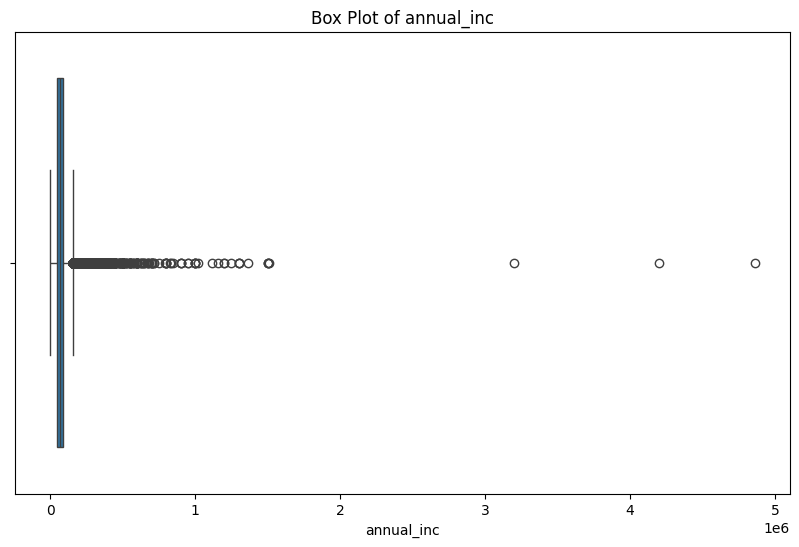

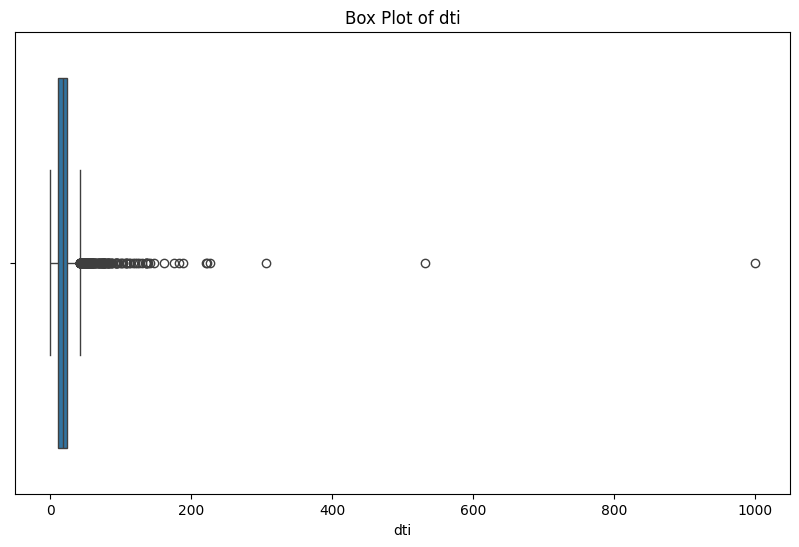

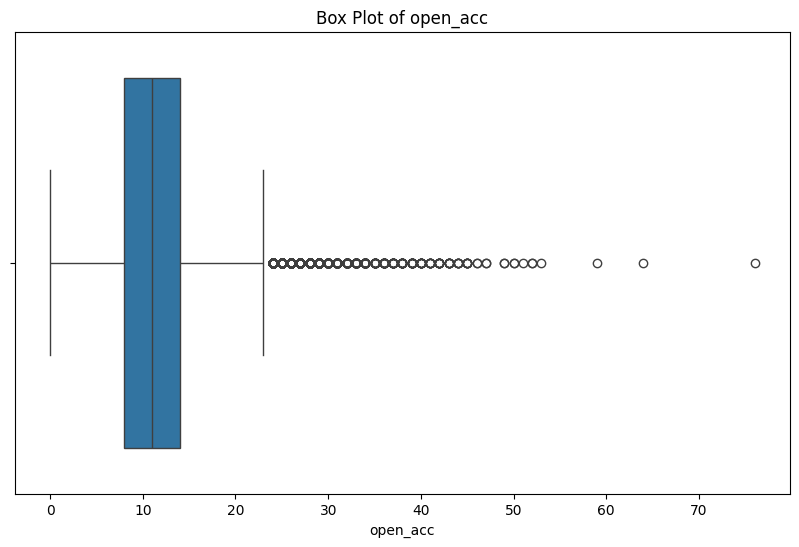

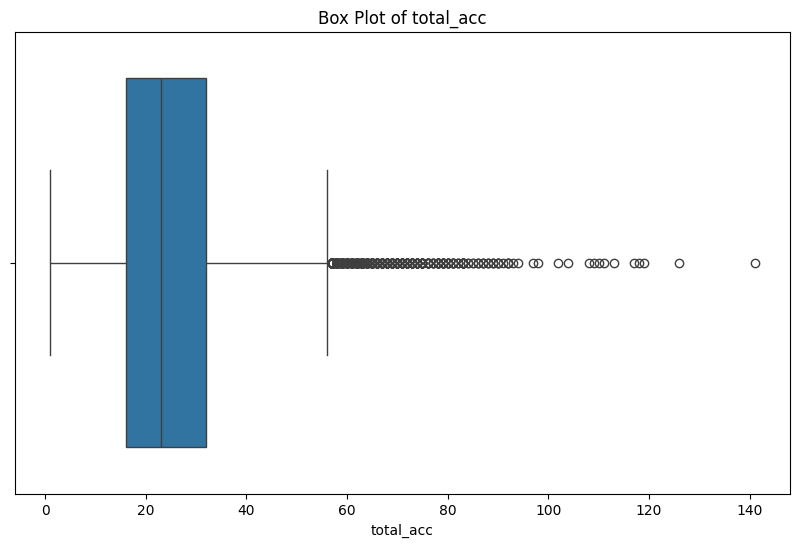

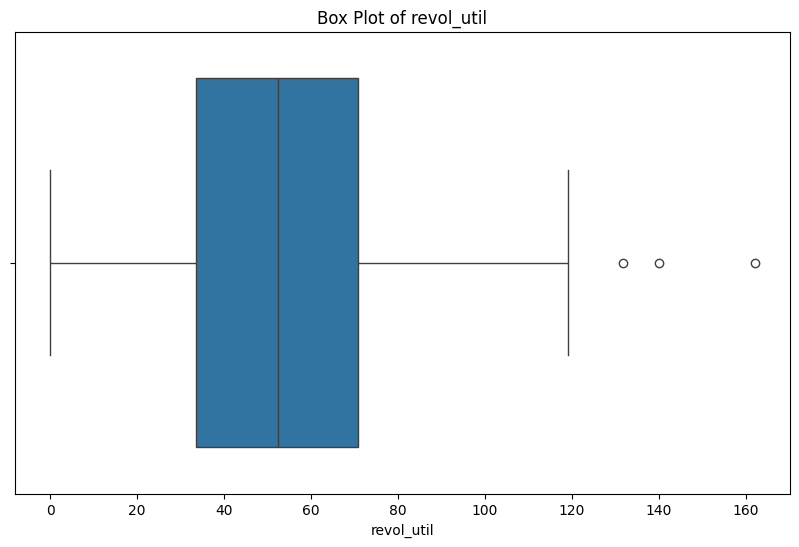

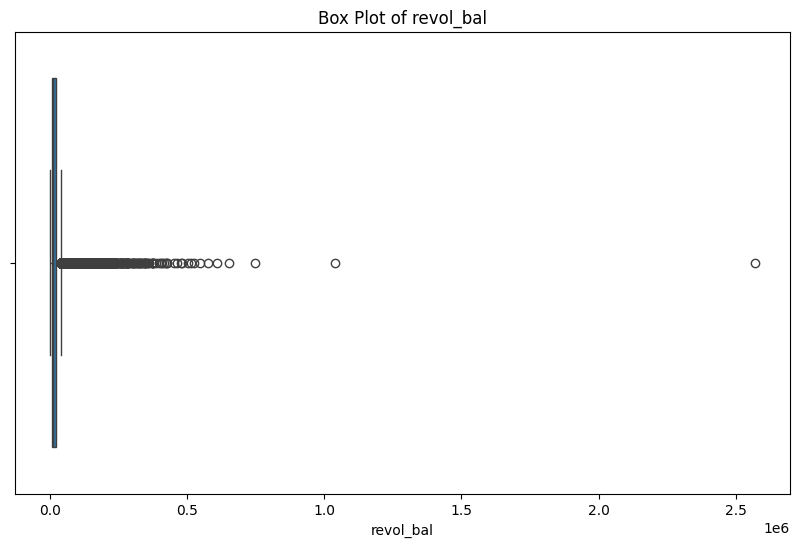

In [787]:
columns_to_plot = ['annual_inc', 'dti', 'open_acc','total_acc', 'revol_util', 'revol_bal']

for col in columns_to_plot:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=fillna_df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

In [788]:
RemoveOutlier_df = fillna_df.copy()

In [789]:
print("Dataset before removing outlier:",RemoveOutlier_df.shape)

Dataset before removing outlier: (61178, 97)


In [790]:
RemoveOutlier_df[RemoveOutlier_df['annual_inc'] > 250000]['loan_condition_int'].value_counts()

loan_condition_int
0    531
1     99
Name: count, dtype: int64

In [791]:
RemoveOutlier_df = RemoveOutlier_df[RemoveOutlier_df['annual_inc'] <= 250000]

In [792]:
RemoveOutlier_df.shape

(60548, 97)

In [793]:
RemoveOutlier_df = RemoveOutlier_df[RemoveOutlier_df['dti'] <= 50]

In [794]:
RemoveOutlier_df.shape

(60392, 97)

In [795]:
RemoveOutlier_df[RemoveOutlier_df['open_acc'] > 40]

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,loan_condition_int,emp_length_int,region
4779,16000,16000,16000.00000,36 months,9.71,514.10,B,B1,RENT,79000.0,...,134700.0,10669.0,93900.0,0.0,N,Cash,N,0,6.0,NorthEast
7792,8500,8500,8500.00000,36 months,12.29,283.51,C,C1,MORTGAGE,82800.0,...,320106.0,185409.0,10000.0,168526.0,N,Cash,N,0,10.0,MidWest
10483,8000,8000,8000.00000,36 months,14.49,275.33,C,C4,RENT,32000.0,...,176794.0,170750.0,11500.0,159594.0,N,Cash,N,1,1.0,SouthEast
10794,40000,40000,40000.00000,60 months,12.61,902.16,C,C1,MORTGAGE,140000.0,...,564925.0,84682.0,231400.0,47925.0,N,Cash,N,0,2.0,SouthEast
10984,30000,30000,30000.00000,36 months,10.49,974.94,B,B2,MORTGAGE,165000.0,...,449289.0,132970.0,10000.0,161301.0,N,Cash,N,0,5.0,SouthWest
11405,5700,5700,5700.00000,36 months,10.41,185.03,B,B3,RENT,60000.0,...,161831.0,168212.0,10900.0,141931.0,N,Cash,N,0,0.5,SouthWest
11478,35000,35000,35000.00000,36 months,11.47,1153.67,B,B5,RENT,245524.0,...,273464.0,171791.0,211800.0,35988.0,N,Cash,N,0,10.0,SouthEast
12480,20150,20150,20150.00000,60 months,17.86,510.15,D,D5,MORTGAGE,55000.0,...,218829.0,27481.0,60800.0,17043.0,N,Cash,N,1,10.0,SouthEast
12992,8000,8000,8000.00000,36 months,6.99,246.99,A,A2,MORTGAGE,200000.0,...,824897.0,2892.0,323000.0,0.0,N,Cash,N,0,4.0,SouthEast
13065,6000,6000,5603.39000,36 months,7.68,187.14,A,A2,OWN,75000.0,...,0.0,0.0,0.0,0.0,N,Cash,N,0,10.0,NorthEast


In [796]:
RemoveOutlier_df =RemoveOutlier_df[RemoveOutlier_df['open_acc'] <= 40]

In [797]:
RemoveOutlier_df

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,loan_condition_int,emp_length_int,region
0,28000,28000,28000.0,36 months,6.62,859.71,A,A2,MORTGAGE,125000.0,...,303786.0,82341.0,6100.0,68795.0,N,Cash,N,0,10.0,NorthEast
1,10650,10650,10650.0,36 months,25.11,424.07,F,F1,MORTGAGE,83000.0,...,234468.0,35276.0,10700.0,37183.0,N,Cash,N,0,10.0,West
3,3975,3975,3975.0,36 months,17.99,143.69,D,D2,ANY,43000.0,...,46857.0,31940.0,4000.0,33457.0,N,Cash,N,0,2.0,SouthEast
6,15000,15000,15000.0,36 months,6.24,457.97,A,A2,MORTGAGE,231800.0,...,692644.0,129514.0,72000.0,132000.0,N,Cash,N,0,8.0,SouthEast
8,8000,8000,8000.0,36 months,9.67,256.90,B,B1,MORTGAGE,72000.0,...,167050.0,24434.0,11000.0,20350.0,N,Cash,N,0,10.0,MidWest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99992,35000,35000,35000.0,60 months,17.57,880.61,D,D4,MORTGAGE,95000.0,...,494525.0,41796.0,30500.0,24088.0,N,Cash,N,0,10.0,SouthEast
99996,13000,13000,13000.0,36 months,13.11,438.72,B,B4,RENT,45000.0,...,62476.0,40178.0,11000.0,41876.0,N,Cash,N,0,8.0,West
99997,2500,2500,2500.0,36 months,15.61,87.42,D,D1,MORTGAGE,45000.0,...,134200.0,17251.0,13300.0,2405.0,N,Cash,N,0,2.0,MidWest
99998,14400,14400,14400.0,60 months,9.17,300.11,B,B2,RENT,48860.0,...,301846.0,40123.0,38100.0,37671.0,N,Cash,N,1,8.0,SouthEast


In [798]:
RemoveOutlier_df[RemoveOutlier_df['total_acc'] > 80]

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,loan_condition_int,emp_length_int,region
423,6000,6000,6000.0,36 months,12.74,201.42,C,C1,OWN,100000.0,...,142901.0,48204.0,4800.0,62218.0,N,Cash,N,0,3.0,SouthWest
2182,10000,10000,10000.0,36 months,6.97,308.64,A,A3,MORTGAGE,87000.0,...,492734.0,157099.0,10500.0,151687.0,N,Cash,N,0,9.0,SouthWest
9420,6000,6000,6000.0,36 months,8.67,189.88,B,B1,MORTGAGE,114000.0,...,589292.0,35902.0,51000.0,24092.0,N,Cash,N,0,10.0,SouthWest
10072,6000,6000,6000.0,36 months,11.99,199.26,C,C1,MORTGAGE,75000.0,...,246926.0,65604.0,8000.0,86904.0,N,Cash,N,0,10.0,MidWest
10201,8000,8000,8000.0,36 months,14.33,274.71,C,C5,RENT,63000.0,...,77804.0,57279.0,13400.0,62804.0,N,Cash,N,0,10.0,SouthEast
10869,7200,7200,7200.0,36 months,16.14,253.63,C,C4,MORTGAGE,89844.0,...,378903.0,133624.0,18100.0,89603.0,N,Cash,N,0,10.0,SouthEast
11343,24000,24000,24000.0,60 months,24.50,697.42,F,F3,MORTGAGE,96000.0,...,115150.0,56724.0,300.0,50660.0,N,Cash,N,0,7.0,SouthWest
14452,11500,11500,10375.0,36 months,10.38,373.13,B,B1,RENT,125000.0,...,0.0,0.0,0.0,0.0,N,Cash,N,0,4.0,West
15194,6500,6500,6500.0,36 months,17.57,233.60,D,D4,MORTGAGE,158000.0,...,309504.0,135294.0,18300.0,131254.0,N,Cash,N,0,9.0,SouthWest
15271,7000,7000,7000.0,36 months,19.24,257.45,E,E2,RENT,45000.0,...,253440.0,230058.0,20000.0,221140.0,N,Cash,Y,1,0.5,SouthEast


In [799]:
RemoveOutlier_df = RemoveOutlier_df[RemoveOutlier_df['total_acc'] <= 80]

In [800]:
RemoveOutlier_df

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,loan_condition_int,emp_length_int,region
0,28000,28000,28000.0,36 months,6.62,859.71,A,A2,MORTGAGE,125000.0,...,303786.0,82341.0,6100.0,68795.0,N,Cash,N,0,10.0,NorthEast
1,10650,10650,10650.0,36 months,25.11,424.07,F,F1,MORTGAGE,83000.0,...,234468.0,35276.0,10700.0,37183.0,N,Cash,N,0,10.0,West
3,3975,3975,3975.0,36 months,17.99,143.69,D,D2,ANY,43000.0,...,46857.0,31940.0,4000.0,33457.0,N,Cash,N,0,2.0,SouthEast
6,15000,15000,15000.0,36 months,6.24,457.97,A,A2,MORTGAGE,231800.0,...,692644.0,129514.0,72000.0,132000.0,N,Cash,N,0,8.0,SouthEast
8,8000,8000,8000.0,36 months,9.67,256.90,B,B1,MORTGAGE,72000.0,...,167050.0,24434.0,11000.0,20350.0,N,Cash,N,0,10.0,MidWest
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99992,35000,35000,35000.0,60 months,17.57,880.61,D,D4,MORTGAGE,95000.0,...,494525.0,41796.0,30500.0,24088.0,N,Cash,N,0,10.0,SouthEast
99996,13000,13000,13000.0,36 months,13.11,438.72,B,B4,RENT,45000.0,...,62476.0,40178.0,11000.0,41876.0,N,Cash,N,0,8.0,West
99997,2500,2500,2500.0,36 months,15.61,87.42,D,D1,MORTGAGE,45000.0,...,134200.0,17251.0,13300.0,2405.0,N,Cash,N,0,2.0,MidWest
99998,14400,14400,14400.0,60 months,9.17,300.11,B,B2,RENT,48860.0,...,301846.0,40123.0,38100.0,37671.0,N,Cash,N,1,8.0,SouthEast


In [801]:
RemoveOutlier_df = RemoveOutlier_df[RemoveOutlier_df['revol_util'] <= 120]
RemoveOutlier_df = RemoveOutlier_df[RemoveOutlier_df['revol_bal'] <= 250000]
RemoveOutlier_df.reset_index(drop=True, inplace=True)
print("Dataset after removing outlier:",RemoveOutlier_df.shape)

Dataset after removing outlier: (60253, 97)


In [802]:
RemoveOutlier_df.head().transpose()

,0,1,2,3,4
loan_amnt,28000,10650,3975,15000,8000
funded_amnt,28000,10650,3975,15000,8000
funded_amnt_inv,28000.0,10650.0,3975.0,15000.0,8000.0
term,36 months,36 months,36 months,36 months,36 months
int_rate,6.62,25.11,17.99,6.24,9.67
...,...,...,...,...,...
disbursement_method,Cash,Cash,Cash,Cash,Cash
debt_settlement_flag,N,N,N,N,N
loan_condition_int,0,0,0,0,0
emp_length_int,10.0,10.0,2.0,8.0,10.0


# Correlation Analysis

In [803]:
corr_df = RemoveOutlier_df.copy()
print(corr_df.columns.tolist())

['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'pymnt_plan', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'last_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il

In [804]:
target_variable = "loan_condition_int"

In [805]:
corr_df['loan_condition_int'].dtype

dtype('int32')

In [806]:
corr_df['loan_condition_int'] = corr_df['loan_condition_int'].astype('int64')

In [807]:
target_variable = 'loan_condition_int'
correlation_with_loan_condition = corr_df.select_dtypes(include=['int64', 'float64']).corr()[target_variable]
sorted_correlation = correlation_with_loan_condition.drop(target_variable).sort_values(ascending=False)

In [808]:
target_variable = 'loan_condition_int'
correlation_with_loan_condition = corr_df.select_dtypes(include=['int64', 'float64']).corr()[target_variable]
sorted_correlation = correlation_with_loan_condition.drop(target_variable).sort_values(ascending=False)

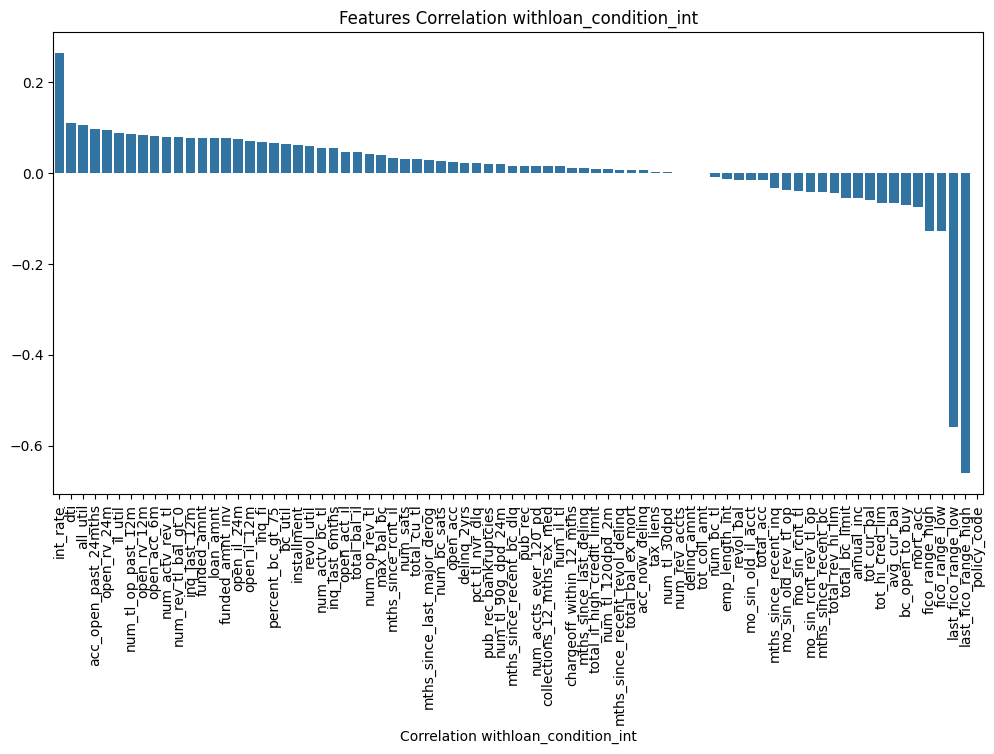

int_rate                0.263249
dti                     0.108784
all_util                0.104183
acc_open_past_24mths    0.095598
open_rv_24m             0.095068
                          ...   
fico_range_high        -0.127440
fico_range_low         -0.127441
last_fico_range_low    -0.559323
last_fico_range_high   -0.660207
policy_code                  NaN
Name: loan_condition_int, Length: 78, dtype: float64


In [809]:
plt.figure(figsize=(12, 6))
sns.barplot(x=sorted_correlation.index, y=sorted_correlation.values, orient='v')
plt.xlabel('Correlation with{}'.format(target_variable))
plt.title('Features Correlation with{}'.format(target_variable))
plt.xticks(rotation=90)
plt.show()
print(sorted_correlation)

In [810]:
sorted_correlation.to_list()

[0.2632487833057987,
 0.10878350202448735,
 0.10418333180826911,
 0.0955975189088078,
 0.09506820285166973,
 0.08660617401025396,
 0.08444379388293344,
 0.08420458710389485,
 0.08119435308091147,
 0.07848247462936629,
 0.07793592645156126,
 0.07680761075125415,
 0.07675659147640396,
 0.07664706714882609,
 0.07632564094803056,
 0.07346980652092328,
 0.06929678589773652,
 0.06677505275984068,
 0.06503858254189274,
 0.06309697039206931,
 0.06107463053029191,
 0.058345354488767535,
 0.05439576223477215,
 0.053585171395589076,
 0.04656941550339082,
 0.04615050934520323,
 0.040898021033369314,
 0.03829432449890373,
 0.03147200798426592,
 0.031141051858085814,
 0.02994202833910385,
 0.02878999957339835,
 0.026631990598747834,
 0.022752551573108647,
 0.022268142362862387,
 0.02166802733783374,
 0.01958115635251444,
 0.018408969749093066,
 0.015500254687782421,
 0.015279273698323268,
 0.015145479353622407,
 0.0146396272982463,
 0.014483707239760654,
 0.009939024666042904,
 0.00979821982347036,


In [811]:
#  Select the variables with the highest correlation with the dependent variable and explore the correlation between them
top_variables = sorted_correlation.abs().nlargest(10).index.tolist()

In [812]:
top_variables

['last_fico_range_high',
 'last_fico_range_low',
 'int_rate',
 'fico_range_low',
 'fico_range_high',
 'dti',
 'all_util',
 'acc_open_past_24mths',
 'open_rv_24m',
 'il_util']

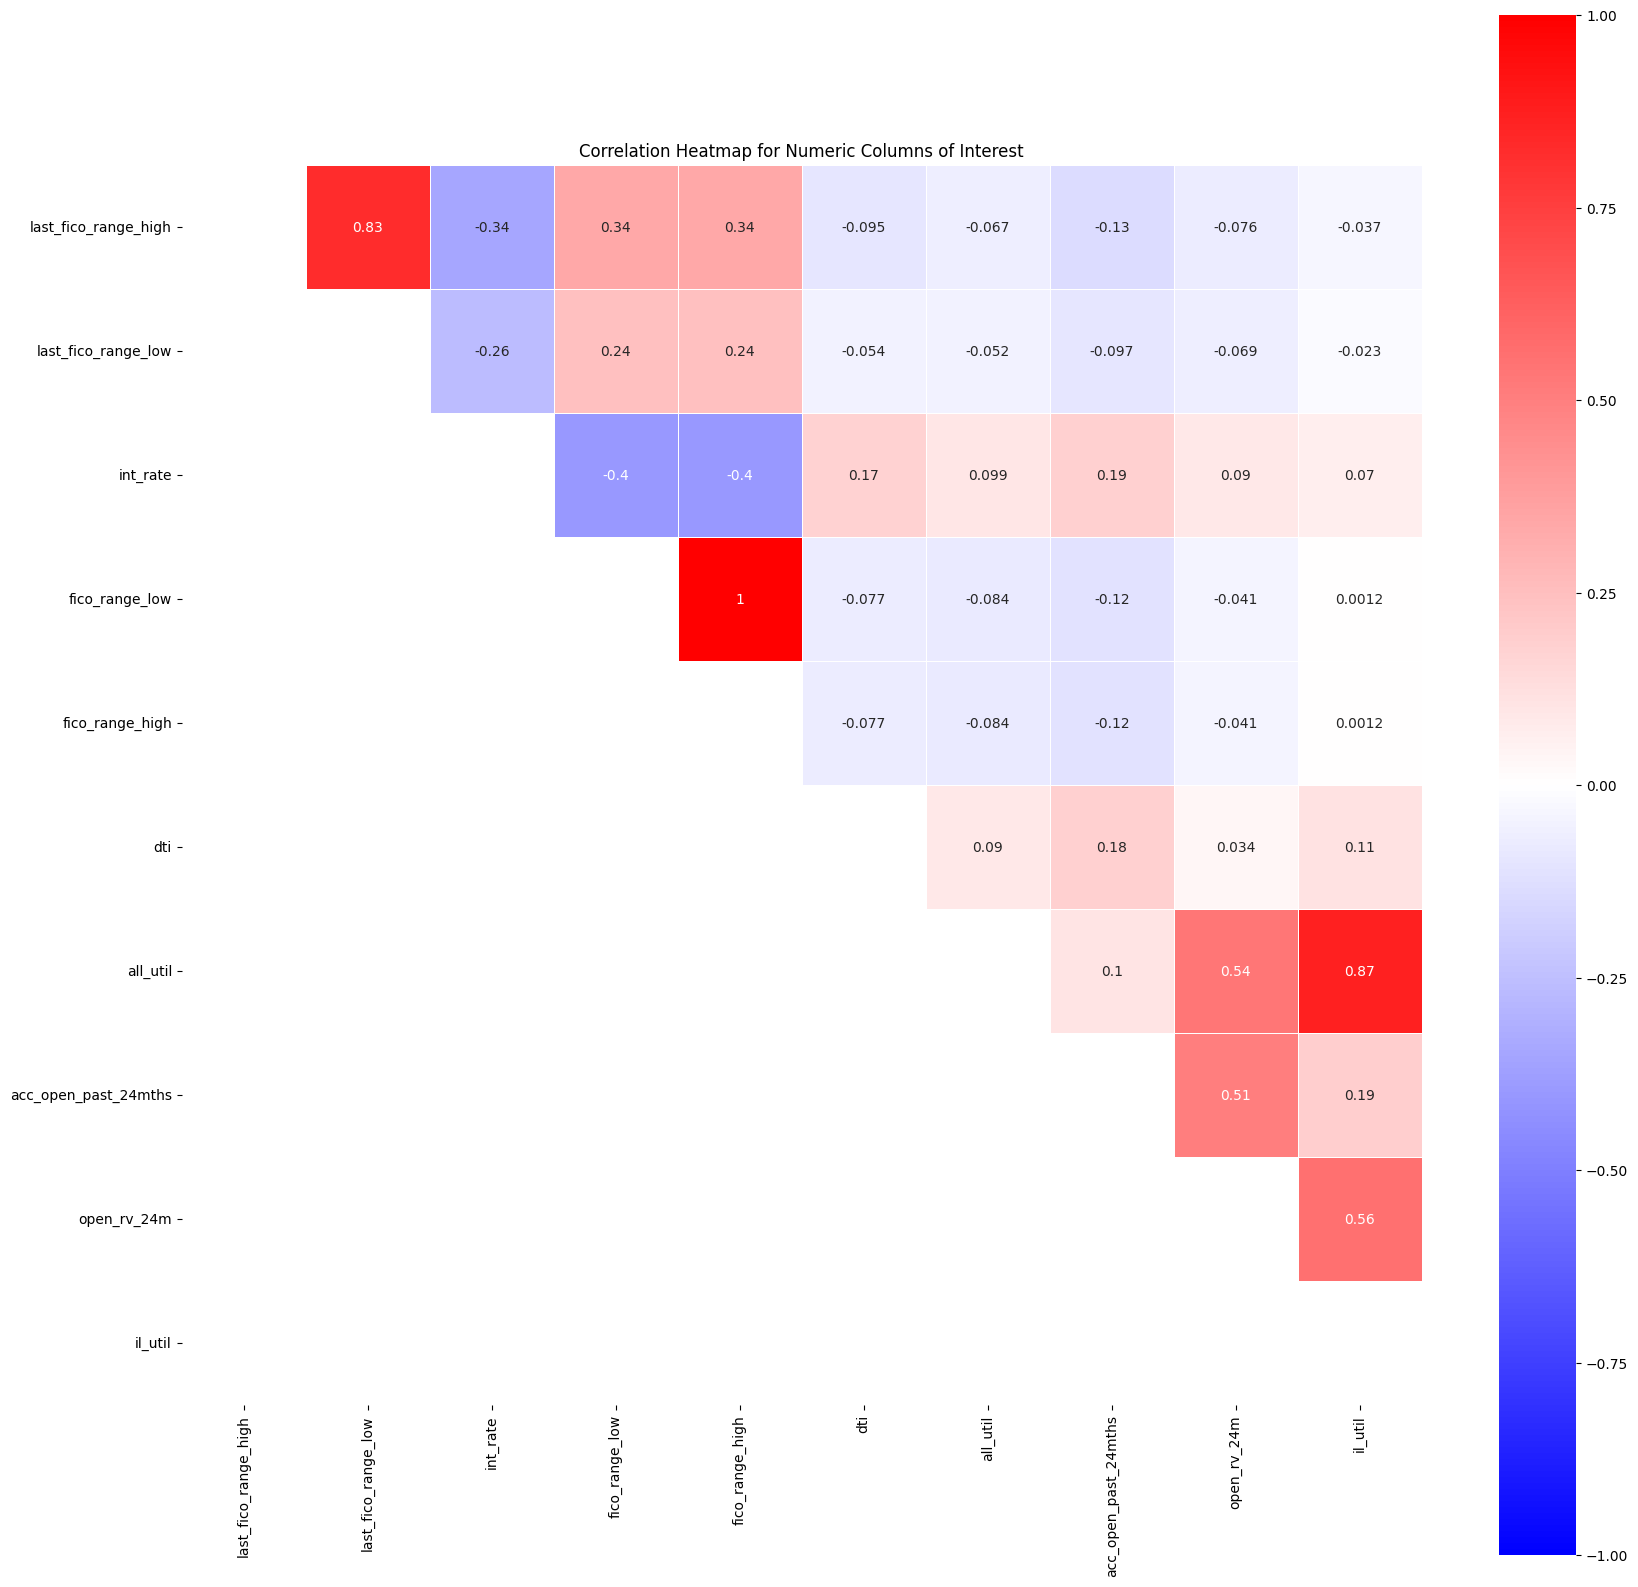

In [813]:
plt.figure(figsize=(20, 20))
correlation_matrix = RemoveOutlier_df[top_variables].corr()
mask = np.tril(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, annot=True, cmap='bwr', vmin=-1, vmax=1, square=True, linewidths=0.5, mask=mask)
plt.title('Correlation Heatmap for Numeric Columns of Interest')
plt.show()


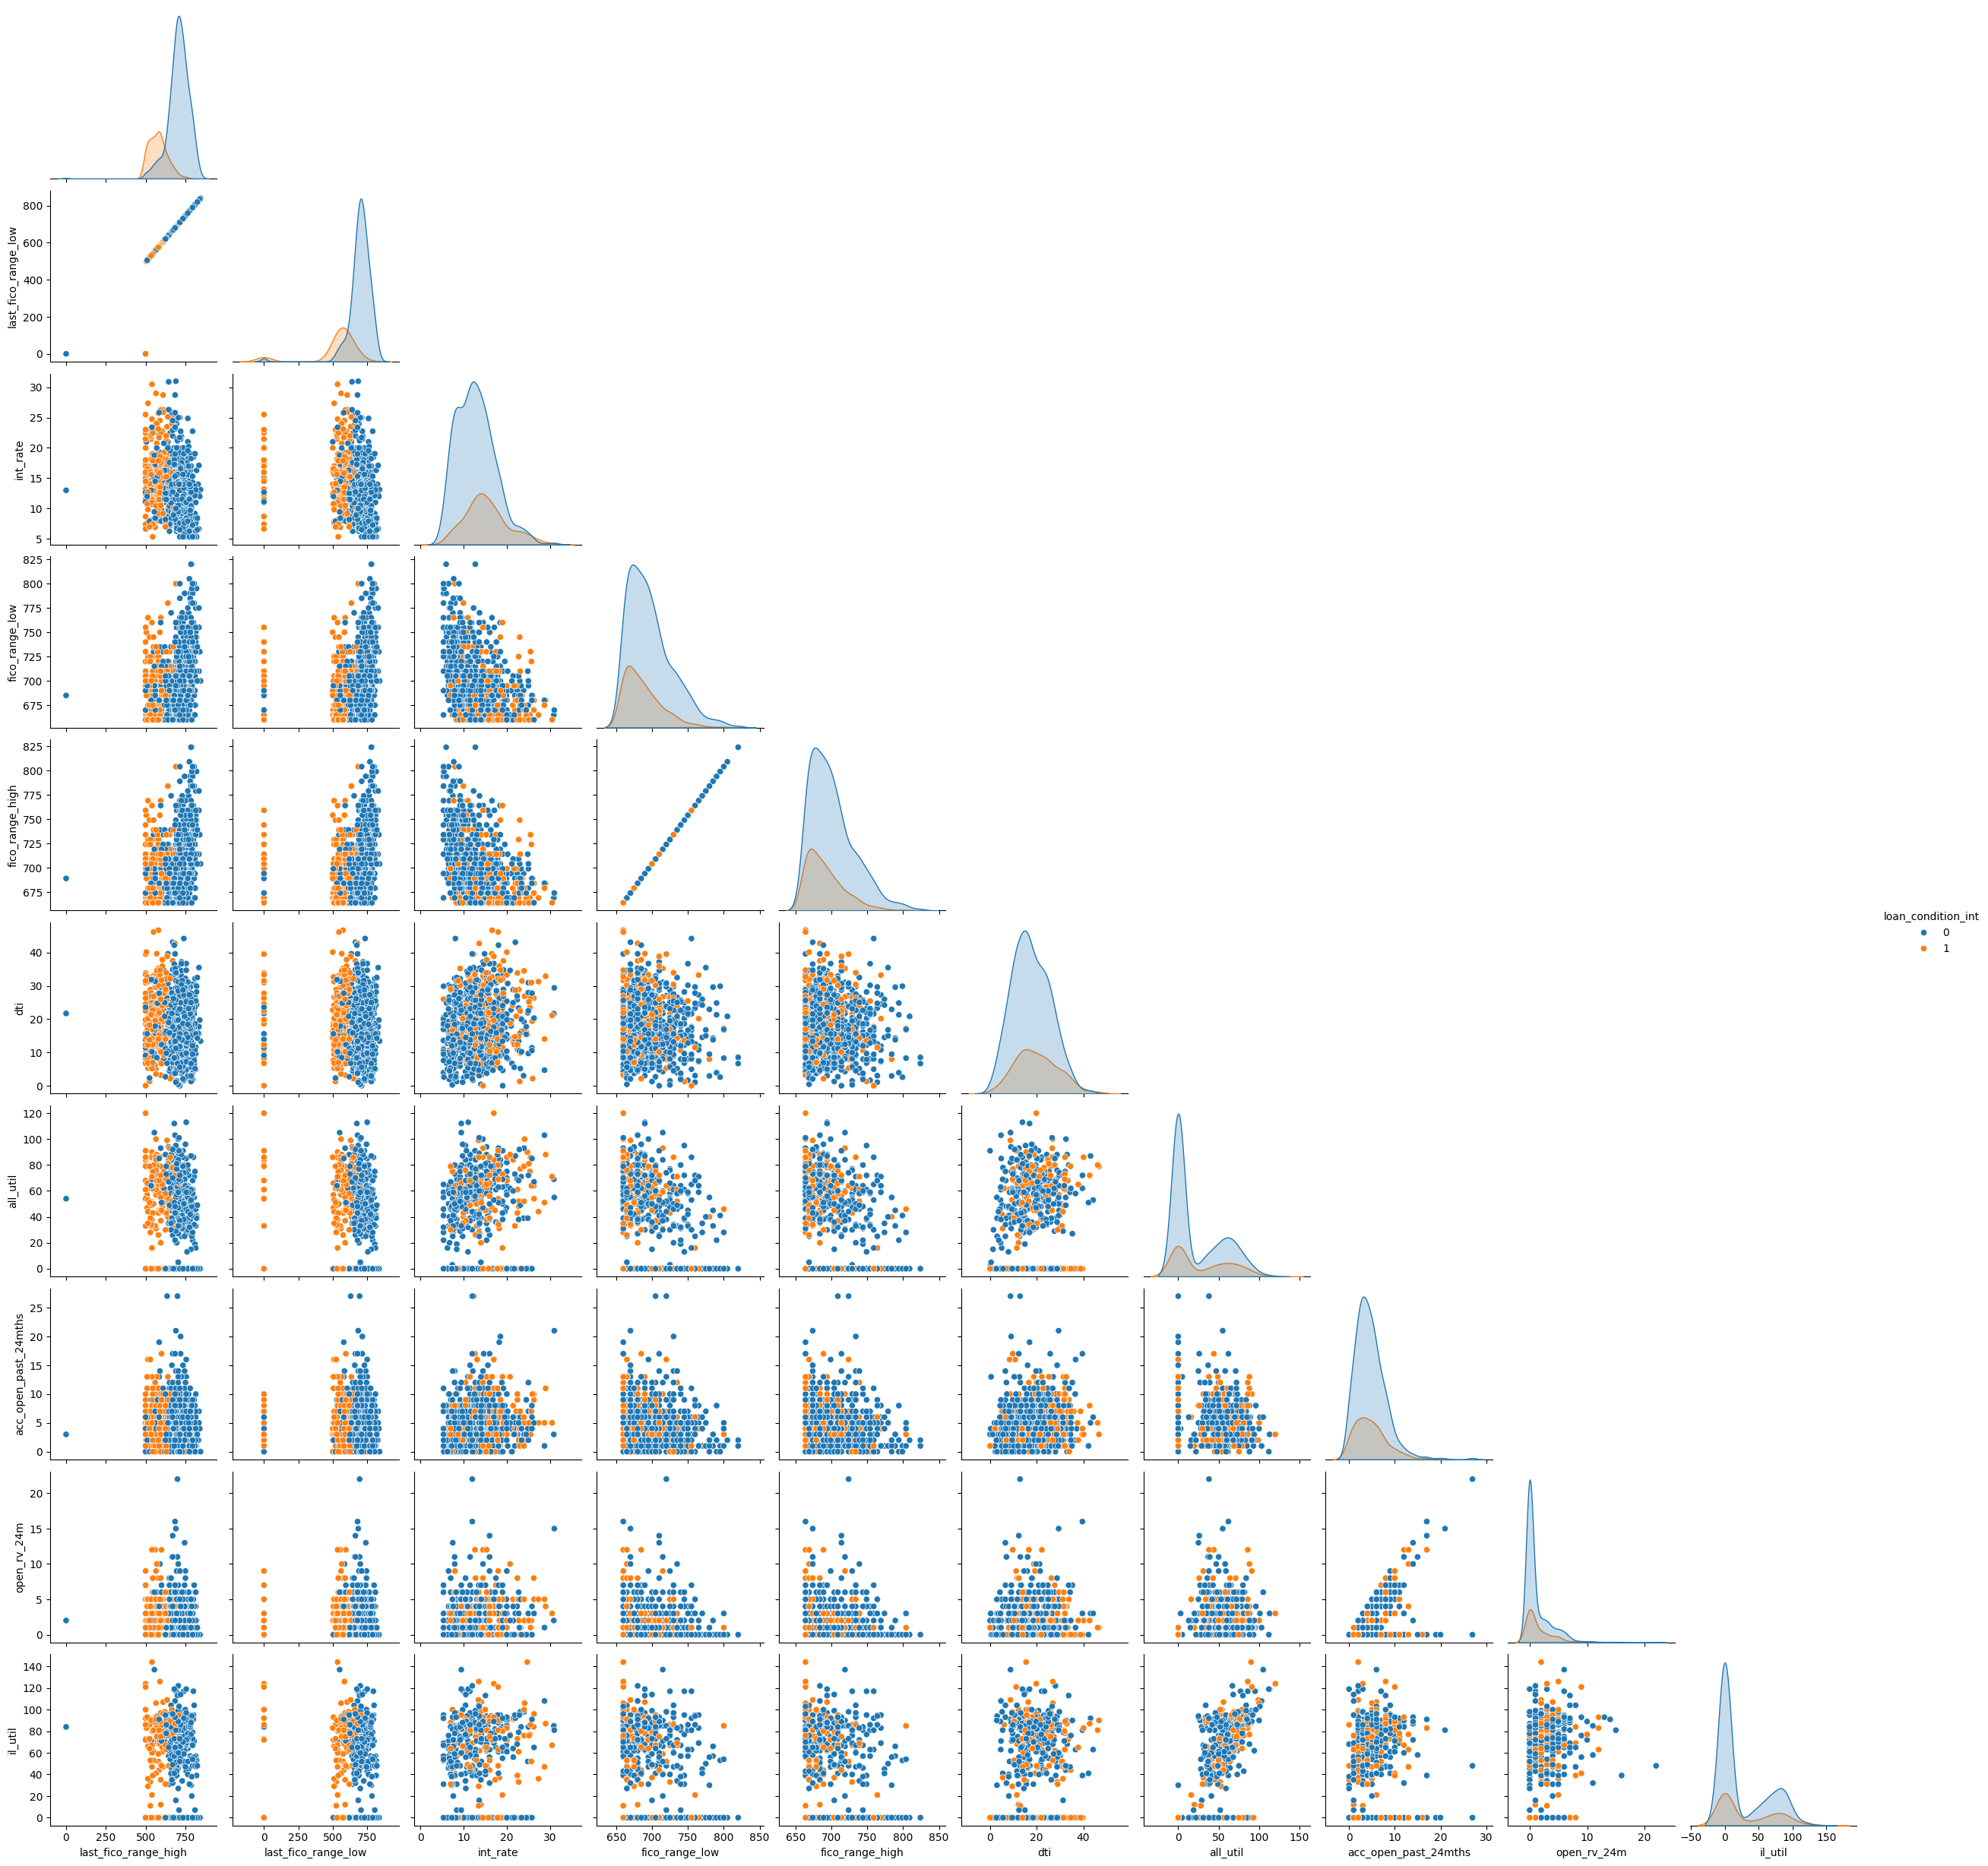

In [814]:
# # Further, explore the specific distribution of the relationship between variables under the action of the dependent variable loan_condition_int
# # This runs a bit slowly, so run with caution
sample_corr_df = corr_df[top_variables + [target_variable]].sample(n=1000, random_state=42)
sns.pairplot(sample_corr_df,hue=target_variable, diag_kind='kde',corner=True)

# Feature engineering

In [815]:
TE_df = RemoveOutlier_df.copy()

In [816]:
TE_df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,loan_condition_int,emp_length_int,region
0,28000,28000,28000.0,36 months,6.62,859.71,A,A2,MORTGAGE,125000.0,...,303786.0,82341.0,6100.0,68795.0,N,Cash,N,0,10.0,NorthEast
1,10650,10650,10650.0,36 months,25.11,424.07,F,F1,MORTGAGE,83000.0,...,234468.0,35276.0,10700.0,37183.0,N,Cash,N,0,10.0,West
2,3975,3975,3975.0,36 months,17.99,143.69,D,D2,ANY,43000.0,...,46857.0,31940.0,4000.0,33457.0,N,Cash,N,0,2.0,SouthEast
3,15000,15000,15000.0,36 months,6.24,457.97,A,A2,MORTGAGE,231800.0,...,692644.0,129514.0,72000.0,132000.0,N,Cash,N,0,8.0,SouthEast
4,8000,8000,8000.0,36 months,9.67,256.90,B,B1,MORTGAGE,72000.0,...,167050.0,24434.0,11000.0,20350.0,N,Cash,N,0,10.0,MidWest


In [817]:
original_cols = TE_df.columns

In [818]:
TE_df.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'pymnt_plan', 'purpose', 'addr_state',
       'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low',
       'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'last_pymnt_d', 'last_credit_pull_d',
       'last_fico_range_high', 'last_fico_range_low',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt',
       'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m',
       'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util',
       'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
       'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths

In [819]:
cat_cols = TE_df.select_dtypes(include=['object']).columns.tolist()

In [820]:
cat_cols

['term',
 'grade',
 'sub_grade',
 'home_ownership',
 'verification_status',
 'issue_d',
 'pymnt_plan',
 'purpose',
 'addr_state',
 'earliest_cr_line',
 'initial_list_status',
 'last_pymnt_d',
 'last_credit_pull_d',
 'application_type',
 'hardship_flag',
 'disbursement_method',
 'debt_settlement_flag',
 'region']

In [821]:
num_cols = [col for col in TE_df.select_dtypes(exclude=['object']).columns.tolist() if col not in ['id', 'loan_condition_int']]

In [822]:
num_cols

['loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'int_rate',
 'installment',
 'annual_inc',
 'dti',
 'delinq_2yrs',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'total_rev_hi_lim',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'mort_acc',
 'mths_since_recent_bc',
 'mths_since_recent_bc_dlq',
 'mths_since_recent_inq',
 'mth

In [823]:
dual_cat_cols = [col for col in cat_cols if TE_df[col].nunique() <= 2]

In [824]:
dual_cat_cols

['term',
 'pymnt_plan',
 'initial_list_status',
 'application_type',
 'hardship_flag',
 'disbursement_method',
 'debt_settlement_flag']

In [825]:
multi_cat_cols = [col for col in cat_cols if TE_df[col].nunique() > 2]

In [826]:
len(multi_cat_cols)

11

In [827]:
multi_cat_cols

['grade',
 'sub_grade',
 'home_ownership',
 'verification_status',
 'issue_d',
 'purpose',
 'addr_state',
 'earliest_cr_line',
 'last_pymnt_d',
 'last_credit_pull_d',
 'region']

In [828]:
# pair all categorical features with another categorical feature
import itertools
def combine_categories(dataframe, cat_cols, expand_dim = False):
    df= dataframe.copy()
    combined = list(itertools.combinations(cat_cols, 2))
    for c1, c2 in combined:
        df.iloc[:, f'{c1}__{c2}'] = df[c1].astype(str) + '_' + df[c2].astype(str)
        if expand_dim:
            cat_cols.append(f'{c1}__{c2}')
    return df, cat_cols

In [829]:
# binary encoding for dual_cat_cols
TE_df = pd.get_dummies(TE_df, columns=dual_cat_cols, drop_first=True)

# update dual_cat_cols
changed_columns = [col for col in TE_df.columns if col not in original_cols]
dual_cat_cols = changed_columns

TE_df.head().transpose()

,0,1,2,3,4
loan_amnt,28000,10650,3975,15000,8000
funded_amnt,28000,10650,3975,15000,8000
funded_amnt_inv,28000.0,10650.0,3975.0,15000.0,8000.0
int_rate,6.62,25.11,17.99,6.24,9.67
installment,859.71,424.07,143.69,457.97,256.9
...,...,...,...,...,...
initial_list_status_w,False,True,True,True,False
application_type_Joint App,False,False,False,False,False
hardship_flag_Y,False,False,False,False,False
disbursement_method_DirectPay,False,False,False,False,False


In [830]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import train_test_split

In [831]:
stratified = StratifiedShuffleSplit(n_splits=1, test_size= 0.2, random_state= 42)

In [832]:
target_variable = 'loan_condition_int'

In [833]:
for train_index, test_index in stratified.split(TE_df, TE_df[target_variable]):
    stratified_train = TE_df.loc[train_index]
    stratified_test = TE_df.loc[test_index]

In [834]:
train_df = stratified_train
test_df = stratified_test

In [835]:
train_df = train_df.sample(frac=1).reset_index(drop=True)
test_df = test_df.sample(frac=1).reset_index(drop=True)

In [836]:
train_df

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,verification_status,...,loan_condition_int,emp_length_int,region,term_ 60 months,pymnt_plan_y,initial_list_status_w,application_type_Joint App,hardship_flag_Y,disbursement_method_DirectPay,debt_settlement_flag_Y
0,20000,20000,20000.0,12.99,673.79,C,C2,MORTGAGE,120000.0,Not Verified,...,0,10.0,West,False,False,True,False,False,False,False
1,5125,5125,5125.0,14.33,175.99,C,C1,RENT,30000.0,Not Verified,...,1,6.0,SouthEast,False,False,False,False,False,False,False
2,5000,5000,5000.0,12.99,168.45,C,C2,OWN,36000.0,Not Verified,...,0,7.0,SouthEast,False,False,True,False,False,False,False
3,2800,2800,2800.0,12.87,94.18,C,C1,MORTGAGE,100843.0,Not Verified,...,0,6.0,West,False,False,False,False,False,False,False
4,12000,12000,12000.0,17.86,303.81,D,D5,OWN,48000.0,Source Verified,...,0,9.0,SouthEast,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48197,6500,6500,6500.0,13.99,222.13,C,C3,RENT,20800.0,Source Verified,...,0,2.0,West,False,False,True,False,False,False,False
48198,7500,7500,7500.0,6.24,228.99,A,A2,MORTGAGE,70000.0,Not Verified,...,0,0.5,SouthEast,False,False,False,False,False,False,False
48199,35000,35000,35000.0,13.35,1185.20,C,C2,MORTGAGE,190000.0,Source Verified,...,0,2.0,MidWest,False,False,True,False,False,False,False
48200,18000,18000,17950.0,19.99,476.79,E,E1,RENT,89000.0,Verified,...,0,6.0,SouthEast,True,False,False,False,False,False,False


In [837]:
test_df

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,verification_status,...,loan_condition_int,emp_length_int,region,term_ 60 months,pymnt_plan_y,initial_list_status_w,application_type_Joint App,hardship_flag_Y,disbursement_method_DirectPay,debt_settlement_flag_Y
0,6900,6900,6900.0,26.30,279.11,E,E5,RENT,33000.0,Source Verified,...,0,10.0,SouthWest,False,False,False,False,False,False,False
1,10425,10425,10425.0,24.08,409.45,F,F2,RENT,35000.0,Verified,...,0,3.0,NorthEast,False,False,False,False,False,False,False
2,12000,12000,12000.0,6.24,366.37,A,A2,RENT,30000.0,Not Verified,...,0,10.0,SouthEast,False,False,True,False,False,False,False
3,10000,10000,10000.0,6.68,307.31,A,A3,RENT,50000.0,Not Verified,...,0,4.0,West,False,False,True,False,False,False,False
4,22400,22400,22400.0,15.31,779.91,C,C5,MORTGAGE,55000.0,Verified,...,0,10.0,SouthWest,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12046,26000,26000,26000.0,13.99,888.50,C,C3,MORTGAGE,84000.0,Verified,...,0,10.0,West,False,False,True,True,False,False,False
12047,15000,15000,0.0,12.86,504.40,D,D1,MORTGAGE,52320.0,Not Verified,...,0,10.0,MidWest,False,False,False,False,False,False,False
12048,8000,8000,8000.0,16.02,281.34,C,C5,OWN,135000.0,Verified,...,0,8.0,West,False,False,True,False,False,False,False
12049,24000,24000,23850.0,12.85,806.93,B,B4,RENT,141242.0,Verified,...,0,10.0,MidWest,False,False,False,False,False,False,False


In [838]:
target_col = 'loan_condition_int'

In [839]:
print(train_df[target_col].value_counts()/len(TE_df))
print(test_df[target_col].value_counts()/len(TE_df))
train_df.shape

loan_condition_int
0    0.625098
1    0.174896
Name: count, dtype: float64
loan_condition_int
0    0.156291
1    0.043716
Name: count, dtype: float64


(48202, 97)

In [840]:
train_y = train_df[[target_col]]
test_y = test_df[[target_col]]

In [841]:
train_X = train_df.drop(target_col, axis = 1, inplace=False)

In [842]:
train_X.shape

(48202, 96)

In [843]:
test_X = test_df.drop(target_col, axis=1, inplace=False)
test_X.shape

(12051, 96)

# Target encoding for multicategorical feature

In [844]:
multi_cat_train_X  = train_X[multi_cat_cols]
multi_cat_test_X = test_X[multi_cat_cols]

In [ ]:
from category_encoders import LeaveOneOutEncoder
from category_encoders import TargetEncoder

In [846]:
encoder = TargetEncoder(smoothing=0.2)
encoder.fit(multi_cat_train_X, train_y)

,verbose,0
,cols,"['grade', 'sub_grade', ...]"
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,min_samples_leaf,20
,smoothing,0.2
,hierarchy,None


In [847]:
encoded_multi_cat_train_X = encoder.transform(multi_cat_train_X)
encoded_multi_cat_test_X = encoder.transform(multi_cat_test_X)


In [848]:
encoded_train_X = pd.concat([train_X.drop(columns=multi_cat_cols), encoded_multi_cat_train_X], axis=1)
encoded_test_X = pd.concat([test_X.drop(columns=multi_cat_cols), encoded_multi_cat_test_X], axis=1)

In [849]:
encoded_train_X.head().transpose()

,0,1,2,3,4
loan_amnt,20000,5125,5000,2800,12000
funded_amnt,20000,5125,5000,2800,12000
funded_amnt_inv,20000.0,5125.0,5000.0,2800.0,12000.0
int_rate,12.99,14.33,12.99,12.87,17.86
installment,673.79,175.99,168.45,94.18,303.81
...,...,...,...,...,...
addr_state,0.186408,0.214724,0.214724,0.208707,0.262366
earliest_cr_line,0.2,0.218622,0.256757,0.2,0.2
last_pymnt_d,0.229738,0.24498,0.214815,0.218622,0.186425
last_credit_pull_d,0.132621,0.266904,0.196957,0.774515,0.157355


# Normalization for Numeric variables

In [850]:
from sklearn.preprocessing import StandardScaler

In [851]:
scaler = StandardScaler()

In [852]:
standardized_train_X = encoded_train_X.copy()
standardized_train_X[num_cols] = scaler.fit_transform(encoded_train_X[num_cols])

In [853]:
standardized_test_X = encoded_test_X.copy()

standardized_test_X[num_cols] = scaler.transform(encoded_test_X[num_cols])

In [854]:
standardized_train_X.head().transpose()

,0,1,2,3,4
loan_amnt,0.654422,-1.06943,-1.083917,-1.338873,-0.272692
funded_amnt,0.655446,-1.069096,-1.083588,-1.338646,-0.272039
funded_amnt_inv,0.658057,-1.065205,-1.079686,-1.334555,-0.26874
int_rate,-0.070622,0.210772,-0.070622,-0.095821,0.952056
installment,0.917892,-1.00495,-1.034075,-1.320956,-0.511223
...,...,...,...,...,...
addr_state,0.186408,0.214724,0.214724,0.208707,0.262366
earliest_cr_line,0.2,0.218622,0.256757,0.2,0.2
last_pymnt_d,0.229738,0.24498,0.214815,0.218622,0.186425
last_credit_pull_d,0.132621,0.266904,0.196957,0.774515,0.157355


# Dealing with Undersampling

In [855]:
from imblearn.under_sampling import RandomUnderSampler

In [856]:
undersampler = RandomUnderSampler(random_state= 42)

In [857]:
standardized_train_X_undersample, train_y_undersample = undersampler.fit_resample(standardized_train_X, train_y) 

In [858]:
standardized_train_X_undersample.shape

(21076, 96)

In [859]:
pd.value_counts(train_y_undersample.loan_condition_int).to_frame()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26204\4002212102.py:1: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(train_y_undersample.loan_condition_int).to_frame()


,count
loan_condition_int,
0,10538
1,10538


# Feature Selection

In [860]:
from sklearn.feature_selection import VarianceThreshold

In [861]:
selector= VarianceThreshold(threshold= 1)
selector.fit(standardized_train_X_undersample)

,threshold,1


In [862]:
filtered_feature_names = standardized_train_X_undersample.columns[selector.get_support()]

In [863]:
standardized_train_X_undersample_filtered= standardized_train_X_undersample[filtered_feature_names]

In [864]:
standardized_train_X_undersample_filtered.shape

(21076, 42)

In [865]:
to_wrap_train_X = standardized_train_X_undersample_filtered.copy()
train_y = train_y_undersample.copy()

In [866]:
nfeatures = len(to_wrap_train_X.columns)
nfeatures

42

In [867]:
vars_final = ['delinq_2yrs',
 'last_fico_range_high',
 'last_fico_range_low',
 'acc_now_delinq',
 'open_acc_6m',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'all_util']

In [868]:
wrapped_train_X = to_wrap_train_X.filter(vars_final, axis=1)
wrapped_test_X = standardized_test_X.filter(vars_final, axis=1)

In [869]:
print("final train/test X shape (target encoded):", wrapped_train_X.shape, wrapped_test_X.shape)
print("final train/test y shape:", train_y.shape, test_y.shape)

final train/test X shape (target encoded): (21076, 9) (12051, 9)
final train/test y shape: (21076, 1) (12051, 1)


In [870]:
wrapped_train_X.head()

,delinq_2yrs,last_fico_range_high,last_fico_range_low,acc_now_delinq,open_acc_6m,total_bal_il,il_util,open_rv_12m,all_util
23259,-0.363123,0.350167,0.313993,-0.066139,-0.459917,-0.456882,-0.685557,-0.472138,-0.751800
15650,-0.363123,0.288757,0.276414,-0.066139,0.622233,1.063713,0.077620,1.156224,0.577581
47786,-0.363123,1.332729,0.915251,-0.066139,-0.459917,-0.456882,-0.685557,-0.472138,-0.751800
28463,-0.363123,0.902858,0.652201,-0.066139,-0.459917,-0.456882,-0.685557,-0.472138,-0.751800
5881,-0.363123,1.087089,0.764937,-0.066139,0.622233,2.851322,2.448920,2.784587,0.261062


Model Building

-  Model_used

Logistic Regression

Decision Tree

K-Nearest Neighbors (KNN)

Random Forest

Gaussian Naive Bayes

LightGBM

XGBoost

Gradient Boosting

Neural Network

-Validation Strategy

We used 5-Fold Cross Validation to evaluate model performance.

In [871]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, recall_score, roc_auc_score

In [872]:
import scipy.stats as sps

In [873]:
def show_confusion_results(matrics_data):
    plt.figure(figsize=(7,5))

    sns.heatmap(matrics_data.T, annot=True, cmap='Blues',fmt='.1f')
    plt.title('Where the Model Got it Right vs. Wrong')
    plt.xlabel('Actual Loan Status (0=Good, 1=Bad)')
    plt.ylabel('What the Model Predicted')
    plt.show()

In [874]:
def get_model_performance(model_obj, train_data, train_label, test_data, test_label):
    # Train the model
    model_obj.fit(train_data, train_label)
    
    # Make predictions
    predictions = model_obj.predict(test_data)
    prob_scores = model_obj.predict_proba(test_data)[:, 1] # Probability of being a 'Bad' loan
    
    # Calculate standard metrics
    acc = accuracy_score(test_label, predictions)
    prec = precision_score(test_label, predictions)
    rec = recall_score(test_label, predictions)
    f1 = f1_score(test_label, predictions)
    auc = roc_auc_score(test_label, prob_scores)
    
    # KS Statistic (Checking how well the model separates the two groups)
    bad_loans = prob_scores[test_label['loan_condition_int'] == 1]
    good_loans = prob_scores[test_label['loan_condition_int'] == 0]
    ks_stat = sps.ks_2samp(bad_loans, good_loans)[0]
    
    # Generate the confusion matrix for this run
    conf_mat = confusion_matrix(test_label, predictions)
    
    return acc, auc, ks_stat, conf_mat, prec, rec, f1

In [877]:
from sklearn.model_selection import KFold

In [ ]:
def run_cross_val(model_obj, X, y):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Lists to store results from each of the 5 folds
    acc_list, auc_list, ks_list, prec_list, rec_list, f1_list = [], [], [], [], [], []
    matrices = []

    for train_idx, test_idx in kf.split(X):
        # Splitting the data
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # scores for this fold
        acc, auc, ks, mat, prec, rec, f1 = get_model_performance(model_obj, X_train, y_train, X_test, y_test)
        
        # Save them
        acc_list.append(acc)
        auc_list.append(auc)
        ks_list.append(ks)
        matrices.append(mat)
        prec_list.append(prec)
        rec_list.append(rec)
        f1_list.append(f1)

    # Calculate the average Confusion Matrix and plot it
    avg_matrix = np.mean(matrices, axis=0)
    show_confusion_results(avg_matrix)
    
    # Return the averages of all scores
    return np.mean(acc_list), np.mean(auc_list), np.mean(ks_list), np.mean(prec_list), np.mean(rec_list), np.mean(f1_list)

In [ ]:
# Comparing all models in a table 
def compare_all_algorithms(model_dictionary, X, y):
    results_table = pd.DataFrame(columns=['Accuracy', 'AUC', 'KS_Stat', 'Precision', 'Recall', 'F1_Score'])
    
    for name, model in model_dictionary.items():
        print(f"Testing: {name}")
        scores = run_cross_val(model, X, y)
        results_table.loc[name] = scores
        
    return results_table

In [ ]:
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline

from imblearn.metrics import classification_report_imbalanced
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression

In [ ]:
# Classifiers
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [880]:
from sklearn.ensemble import BaggingClassifier

In [892]:
models = {
     'Logistic Regression': LogisticRegression(),
     'Decision Tree': DecisionTreeClassifier(max_depth=10,min_samples_split=60,min_samples_leaf=30),
     'K Nearest Neighbors': KNeighborsClassifier(n_neighbors=20),
     'Random Forest': RandomForestClassifier(n_estimators=20,max_depth=10),
     'Gaussian Naive Bayes': GaussianNB(var_smoothing=1),
     'XGBoost': XGBClassifier(n_estimators=50,max_depth=3),
     'Gradient Boosting': GradientBoostingClassifier(n_estimators=50,max_depth=3),
     "Neural Network": MLPClassifier(hidden_layer_sizes = (10,10)),
# #     'Support Vector Machine': SVC()
}

In [893]:
import scipy.stats as sps

Testing: Logistic Regression...


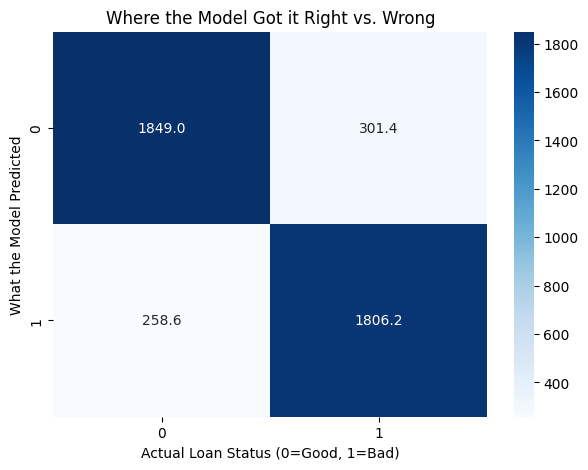

Testing: Decision Tree...


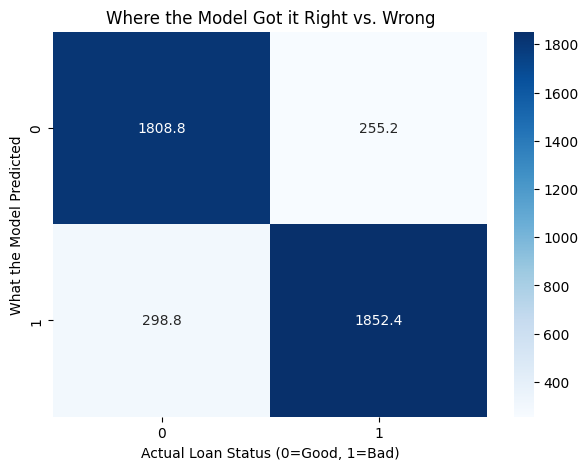

Testing: K Nearest Neighbors...


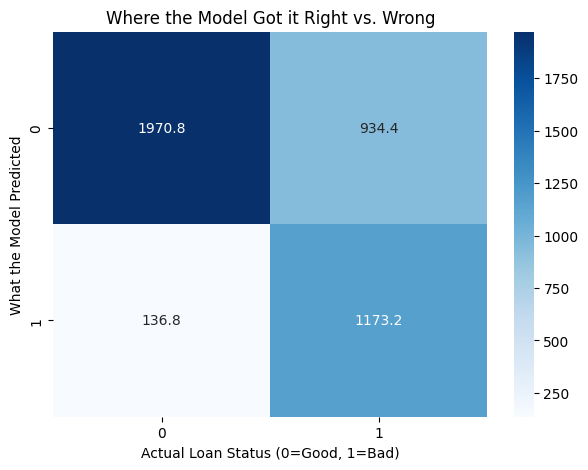

Testing: Random Forest...


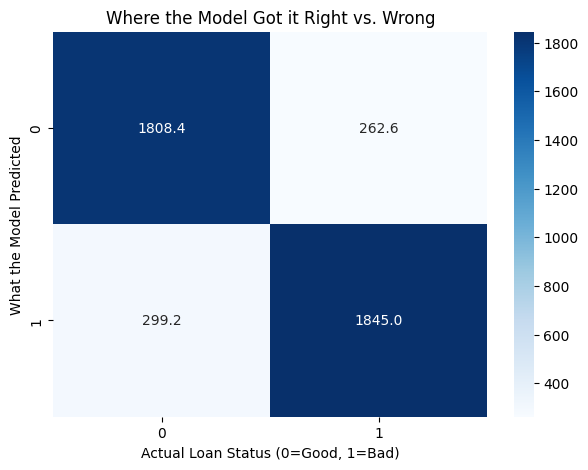

Testing: Gaussian Naive Bayes...


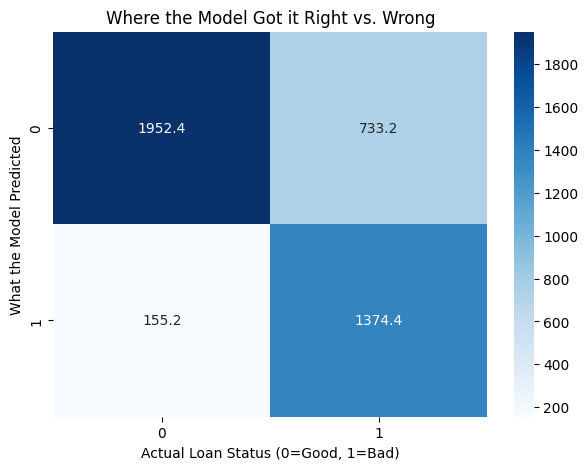

Testing: XGBoost...


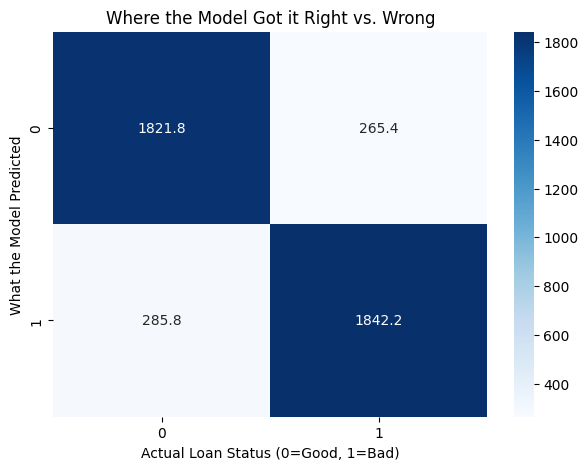

Testing: Gradient Boosting...


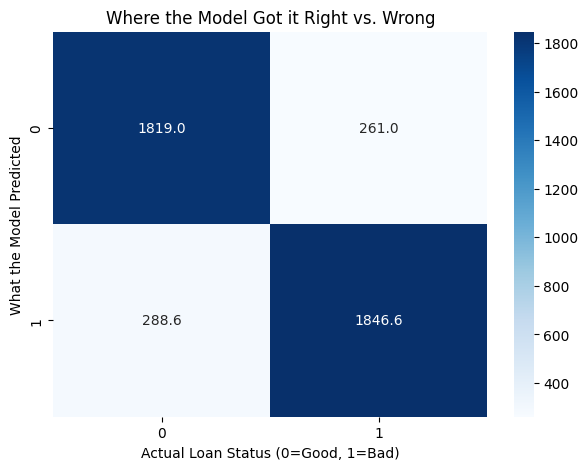

Testing: Neural Network...


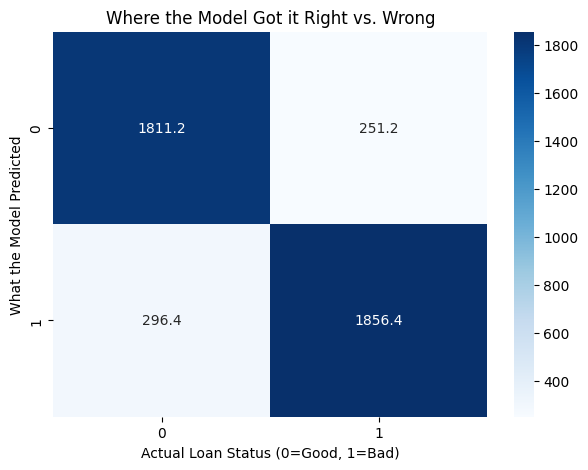

In [894]:
# test models
baseline_tgt = compare_all_algorithms(models, wrapped_train_X, train_y)

In [895]:
baseline_tgt

,Accuracy,AUC,KS_Stat,Precision,Recall,F1_Score
Logistic Regression,0.867147,0.927832,0.741906,0.874731,0.857031,0.865742
Decision Tree,0.868571,0.925752,0.740376,0.861119,0.878911,0.869863
K Nearest Neighbors,0.745871,0.779920,0.532021,0.895427,0.556708,0.686376
Random Forest,0.866720,0.929013,0.738521,0.860427,0.875413,0.867803
Gaussian Naive Bayes,0.789238,0.908363,0.682876,0.898709,0.652293,0.755308
XGBoost,0.869235,0.930685,0.741568,0.865648,0.874096,0.869817
Gradient Boosting,0.869615,0.931640,0.742380,0.864794,0.876198,0.870417
Neural Network,0.870089,0.931428,0.742582,0.862278,0.880866,0.871419


In [ ]:
def calculate_scores(model, X_trn, y_trn, X_tst, y_tst):
    """
    Trains the model and calculates performance metrics 
    on the provided test set.
    """
    # Train the model
    model.fit(X_trn, y_trn)
    
    #  predictions
    y_pred = model.predict(X_tst)
    y_pred_proba = model.predict_proba(X_tst)[:, 1]

    # Calculate all the metrics
    accuracy = accuracy_score(y_tst, y_pred)
    precision = precision_score(y_tst, y_pred)
    recall = recall_score(y_tst, y_pred)
    f1 = f1_score(y_tst, y_pred)
    auc = roc_auc_score(y_tst, y_pred_proba)

    #  Calculate KS Statistic (Separation Power)
    bad_loans = y_pred_proba[y_tst['loan_condition_int'] == 1]
    good_loans = y_pred_proba[y_tst['loan_condition_int'] == 0]
    ks = sps.ks_2samp(bad_loans, good_loans)[0]

    # Create confusion matrix
    conf_matrix = confusion_matrix(y_tst, y_pred)

    return accuracy, auc, ks, conf_matrix, precision, recall, f1

In [ ]:
# This table will show how the models perform on "new" data they haven't seen.
holdout_summary = pd.DataFrame(columns=['accuracy', 'auc', 'ks', 'precision', 'recall', 'f1'])

print("Starting Final Evaluation on the Test Set...")

# Loop through your models and test them 
for name, model in models.items():
    # calculate_scores is the function we defined earlier 
    # It trains on wrapped_train_X and evaluates on wrapped_test_X
    acc, auc, ks, conf_matrix, prec, rec, f1 = calculate_scores(
        model, 
        wrapped_train_X, 
        train_y, 
        wrapped_test_X, 
        test_y
    )
    
    # Save the scores into our summary table
    holdout_summary.loc[name] = [acc, auc, ks, prec, rec, f1]
    
    print(f"Finished evaluating: {name}")

# Display the final results
print("FINAL HOLDOUT PERFORMANCE")
display(holdout_summary)

Starting Final Evaluation on the Test Set...
Finished evaluating: Logistic Regression
Finished evaluating: Decision Tree
Finished evaluating: K Nearest Neighbors
Finished evaluating: Random Forest
Finished evaluating: Gaussian Naive Bayes
Finished evaluating: XGBoost
Finished evaluating: Gradient Boosting
Finished evaluating: Neural Network

--- FINAL HOLDOUT PERFORMANCE ---


,accuracy,auc,ks,precision,recall,f1
Logistic Regression,0.873289,0.928088,0.737159,0.663419,0.853075,0.746388
Decision Tree,0.867729,0.926113,0.739394,0.646810,0.869780,0.741904
K Nearest Neighbors,0.849224,0.757412,0.480878,0.705380,0.532650,0.606965
Random Forest,0.868144,0.929892,0.739938,0.647225,0.872058,0.743005
Gaussian Naive Bayes,0.867563,0.910103,0.684190,0.713580,0.658314,0.684834
XGBoost,0.870467,0.931842,0.741521,0.652718,0.870539,0.746055
Gradient Boosting,0.870467,0.931772,0.742834,0.652632,0.870919,0.746138
Neural Network,0.869057,0.931662,0.745304,0.648231,0.876614,0.745320
